In [27]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pathlib as Path
pd.set_option('display.max_columns', None)

In [18]:
df = pd.read_csv('../data/processed/ipl_features_regular.csv')

print(f"Dataset loaded successfully with {len(df)} rows")

Dataset loaded successfully with 295557 rows


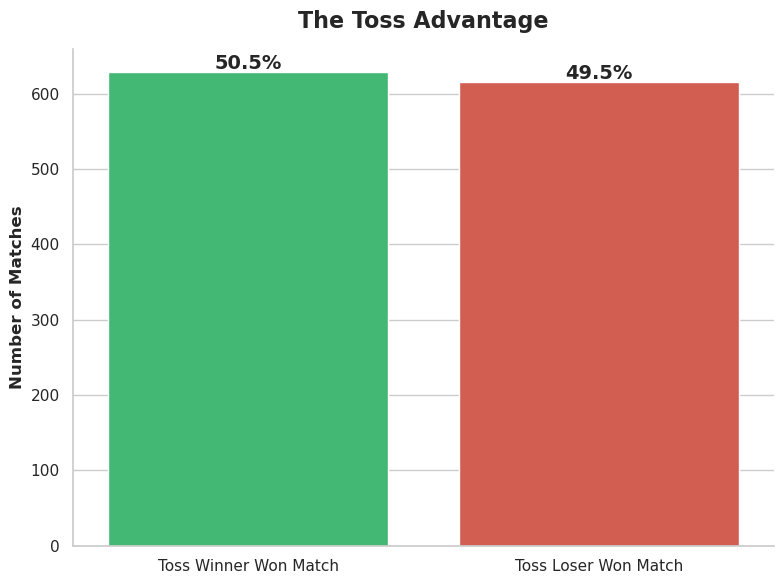

In [3]:
# --- STEP 1: Convert to Match-Level Data ---
# Drop duplicates so we only have exactly 1 row for every unique match_id
match_df = df.drop_duplicates(subset=['match_id']).copy()

# --- STEP 2: Calculate the Toss Impact ---
# Create a simple True/False column if the toss winner also won the match
match_df['toss_winner_won_match'] = match_df['toss_winner'] == match_df['winner']

# Count the exact number of matches
toss_counts = match_df['toss_winner_won_match'].value_counts()
total_matches = len(match_df)

# Calculate the percentages for our chart labels
win_pct = (toss_counts[True] / total_matches) * 100
loss_pct = (toss_counts[False] / total_matches) * 100

# --- STEP 3: Build the Visualization ---
plt.figure(figsize=(8, 6))

# Create the bars using Seaborn
# (Using a nice green for the 'advantage' and red for 'no advantage')
ax = sns.barplot(
    x=['Toss Winner Won Match', 'Toss Loser Won Match'], 
    y=[toss_counts[True], toss_counts[False]],
    palette=['#2ecc71', '#e74c3c'],
    hue=['Toss Winner Won Match', 'Toss Loser Won Match'] # Modern Seaborn requires hue for palettes
)

# Add title and axis labels
plt.title('The Toss Advantage', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Matches', fontsize=12, fontweight='bold')

# Annotate the bars with the exact percentage
ax.text(0, toss_counts[True] + 5, f"{win_pct:.1f}%", ha='center', fontsize=14, fontweight='bold')
ax.text(1, toss_counts[False] + 5, f"{loss_pct:.1f}%", ha='center', fontsize=14, fontweight='bold')

# Strip the top and right borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

In [10]:
df['is_rain_reduced'].dtype

dtype('int64')

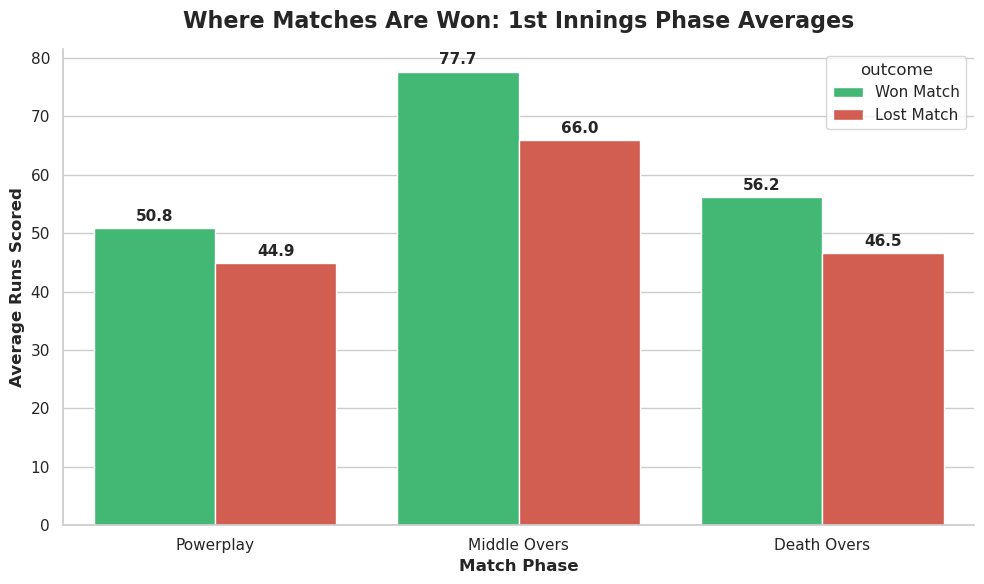

In [ ]:
# --- STEP 1: Isolate 1st Innings & Determine Outcome ---
# Keep only 1st innings to ensure a fair comparison of full 20-over strategies
first_innings = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()

# Create a clear flag: Did the team setting the target actually win the game?
first_innings['outcome'] = np.where(
    first_innings['batting_team'] == first_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs per Phase for Every Match ---
# Group by match, phase, and outcome to sum the runs
phase_totals = first_innings.groupby(
    ['match_id', 'phase', 'outcome']
)['runs_total'].sum().reset_index()


# --- STEP 3: Build the Grouped Bar Chart ---
plt.figure(figsize=(10, 6))

# Seaborn's barplot automatically calculates the mean (average) of our phase_totals
ax = sns.barplot(
    data=phase_totals,
    x='phase',
    y='runs_total',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], # Force logical chronological order
    palette=['#2ecc71', '#e74c3c'], # Green for win, Red for loss
    errorbar=None # Removes the error lines for a cleaner look
)

# Add titles and labels
plt.title('1st Innings Phase Averages', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Average Runs Scored', fontsize=12, fontweight='bold')

# Add the exact numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

# Clean up the borders
sns.despine()

plt.tight_layout()
plt.show()

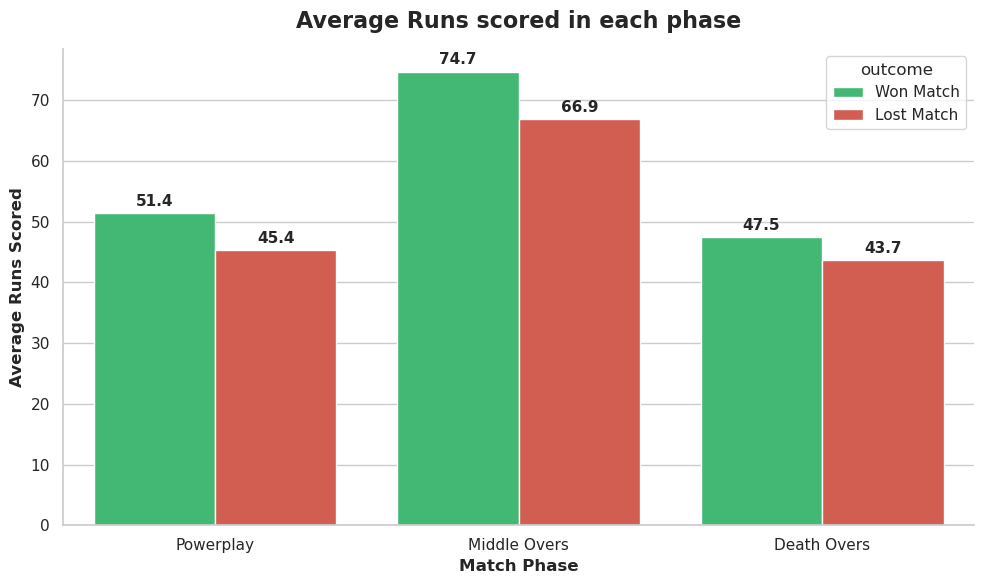

In [7]:
# --- STEP 1: Use BOTH Innings ---
# We keep both 1st and 2nd innings
all_innings = df[df['is_rain_reduced']==0].copy()

all_innings['outcome'] = np.where(
    all_innings['batting_team'] == all_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs ---
# Notice we added 'innings' to the groupby so we don't accidentally merge a team's 1st and 2nd innings!
phase_totals_skewed = all_innings.groupby(
    ['match_id', 'innings', 'phase', 'outcome']
)['runs_total'].sum().reset_index()

# --- STEP 3: Build the Skewed Chart ---
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=phase_totals_skewed,
    x='phase',
    y='runs_total',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], 
    palette=['#2ecc71', '#e74c3c'],
    errorbar=None 
)

plt.title('Average Runs scored in each phase', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Average Runs Scored', fontsize=12, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

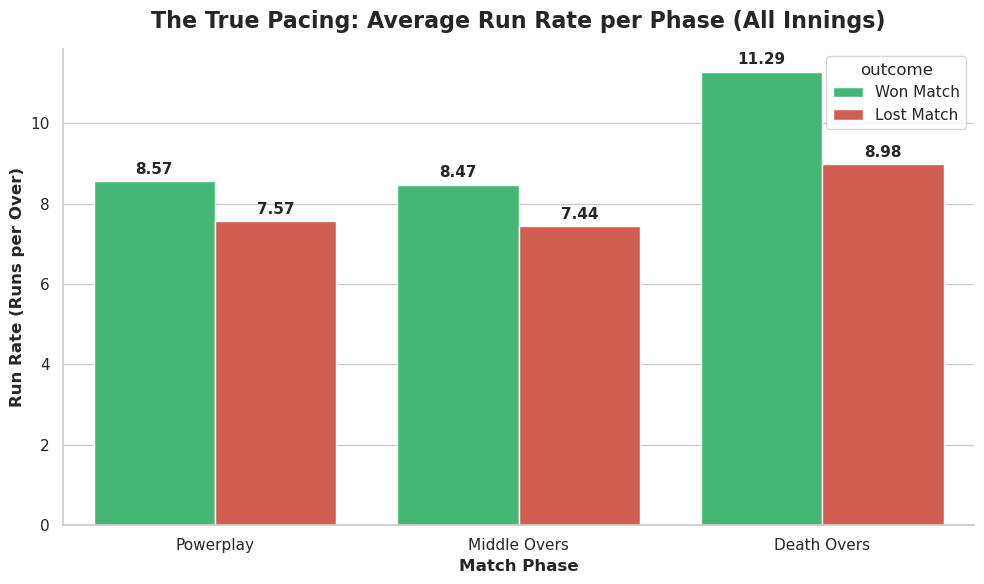

In [8]:
# --- STEP 1: Prep Both Innings ---
# We can safely use the whole regular dataset now!
all_innings = df[df['is_rain_reduced']==0].copy()

# Flag whether the batting team won or lost the match
all_innings['outcome'] = np.where(
    all_innings['batting_team'] == all_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs & Legal Balls per Phase ---
# Group by match, innings, phase, and outcome
phase_stats = all_innings.groupby(['match_id', 'innings', 'phase', 'outcome']).agg(
    total_runs=('runs_total', 'sum'),
    legal_balls=('is_legal_delivery', 'sum')
).reset_index()

# Filter out any weird anomalies where 0 legal balls were bowled to avoid division by zero errors
phase_stats = phase_stats[phase_stats['legal_balls'] > 0].copy()

# --- STEP 3: The Run Rate Math ---
# Formula: (Runs / Balls) * 6
phase_stats['run_rate'] = (phase_stats['total_runs'] / phase_stats['legal_balls']) * 6


# --- STEP 4: Build the True Representation Chart ---
plt.figure(figsize=(10, 6))

# Seaborn will now average out the 'run_rate' column
ax = sns.barplot(
    data=phase_stats,
    x='phase',
    y='run_rate',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], 
    palette=['#2ecc71', '#e74c3c'],
    errorbar=None 
)

plt.title('The True Pacing: Average Run Rate per Phase (All Innings)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Run Rate (Runs per Over)', fontsize=12, fontweight='bold')

# Add the labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_23481/3764818000.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_batters, x='total_runs', y='batter', ax=axes[0], palette='viridis')
/tmp/ipykernel_23481/3764818000.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bowlers, x='total_wickets', y='bowler', ax=axes[1], palette='magma')


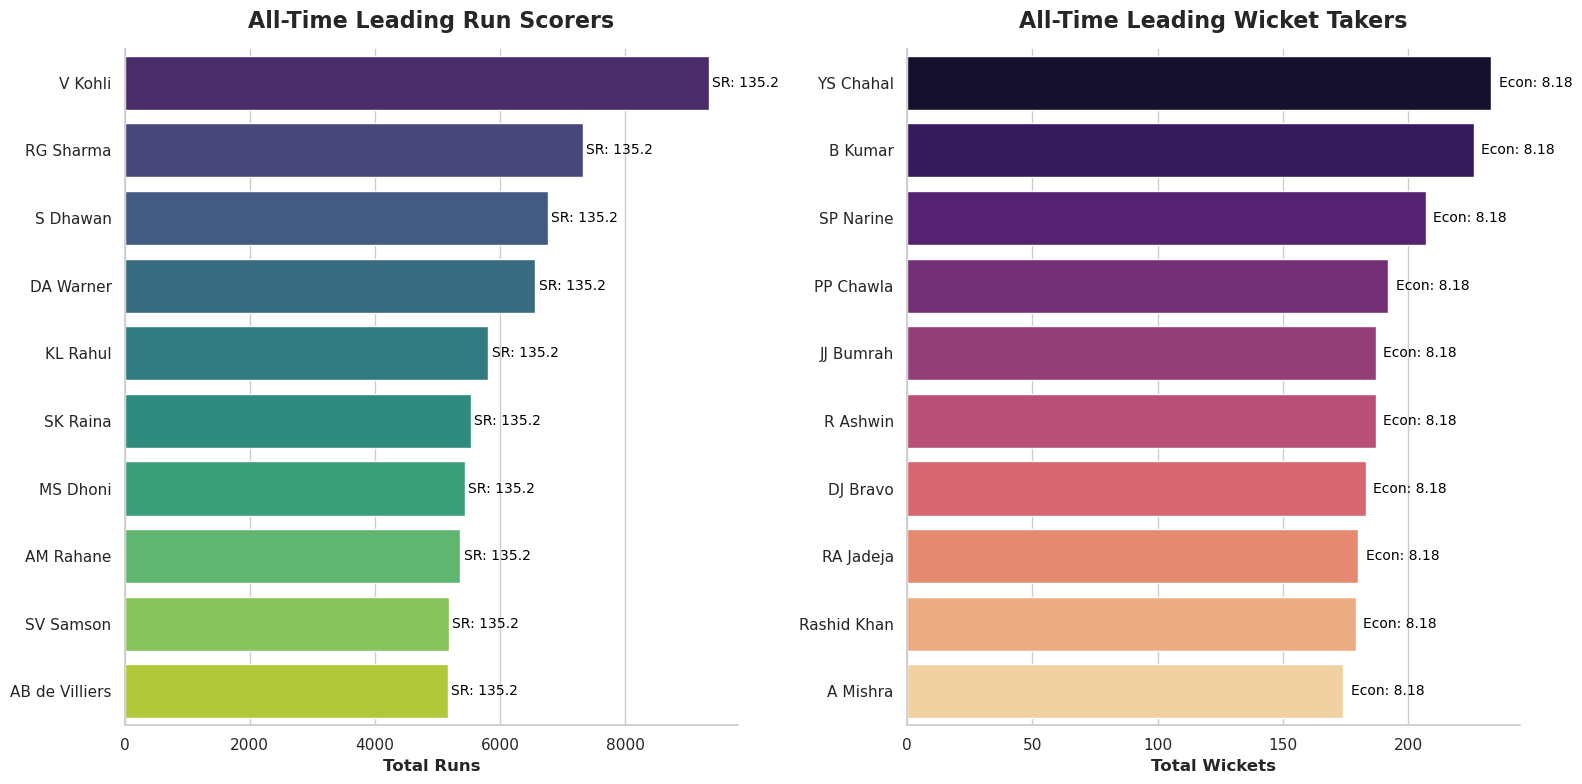

In [7]:
# --- STEP 1: Calculate Batter Stats ---
# Group by batter and calculate total runs and total balls faced
batter_stats = all_innings.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('is_legal_delivery', 'sum') 
).reset_index()

# Calculate Strike Rate (Runs per 100 balls)
batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['balls_faced']) * 100

# Get the Top 10 Run Scorers
top_batters = batter_stats.nlargest(10, 'total_runs')


# --- STEP 2: Calculate Bowler Stats ---
# Define exactly which dismissals belong to the bowler
bowler_dismissals = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# Create a temporary column just for this calculation
all_innings['is_bowler_wicket'] = all_innings['wicket_kind'].isin(bowler_dismissals).astype(int)

# Group by bowler and calculate total wickets and total legal balls bowled
bowler_stats = all_innings.groupby('bowler').agg(
    total_wickets=('is_bowler_wicket', 'sum'),
    balls_bowled=('is_legal_delivery', 'sum'),
    runs_conceded=('runs_total', 'sum') # Using runs_total as a baseline for economy
).reset_index()

# Calculate Economy Rate (Runs conceded per 6 balls)
# Filter out 0 balls bowled to avoid division errors
bowler_stats = bowler_stats[bowler_stats['balls_bowled'] > 0]
bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls_bowled']) * 6

# Get the Top 10 Wicket Takers
top_bowlers = bowler_stats.nlargest(10, 'total_wickets')


# --- STEP 3: Build the Side-by-Side Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Top Batters (Left Side)
sns.barplot(data=top_batters, x='total_runs', y='batter', ax=axes[0], palette='viridis')
axes[0].set_title('All-Time Leading Run Scorers', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Runs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# Add Strike Rate text to the end of each batter's bar
for container in axes[0].containers:
    for i, bar in enumerate(container):
        sr = top_batters.iloc[i]['strike_rate']
        axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
                     f"SR: {sr:.1f}", va='center', fontsize=10, color='black')

# Chart 2: Top Bowlers (Right Side)
sns.barplot(data=top_bowlers, x='total_wickets', y='bowler', ax=axes[1], palette='magma')
axes[1].set_title('All-Time Leading Wicket Takers', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Wickets', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

# Add Economy Rate text to the end of each bowler's bar
for container in axes[1].containers:
    for i, bar in enumerate(container):
        econ = top_bowlers.iloc[i]['economy']
        axes[1].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, 
                     f"Econ: {econ:.2f}", va='center', fontsize=10, color='black')

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

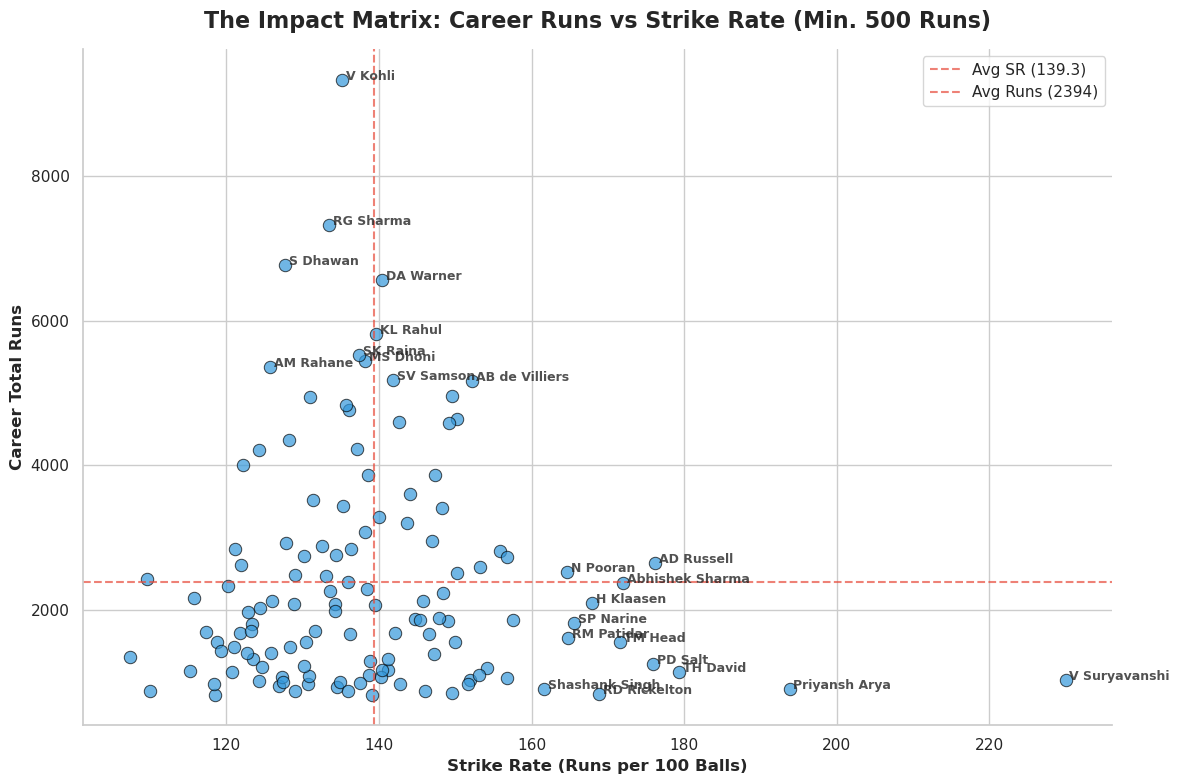

In [8]:
# --- STEP 1: Calculate Career Stats ---
batter_impact = all_innings.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('is_legal_delivery', 'sum')
).reset_index()

# --- STEP 2: The Crucial Volume Filter ---
# Filter out the noise by requiring a minimum of 500 career runs
impact_players = batter_impact[batter_impact['total_runs'] >= 800].copy()

# Calculate Strike Rate for this elite group
impact_players['strike_rate'] = (impact_players['total_runs'] / impact_players['balls_faced']) * 100

# --- STEP 3: Calculate Quadrant Averages ---
avg_runs = impact_players['total_runs'].mean()
avg_sr = impact_players['strike_rate'].mean()

# --- STEP 4: Build the Impact Matrix ---
plt.figure(figsize=(12, 8))

# Draw the scatter plot
sns.scatterplot(
    data=impact_players, 
    x='strike_rate', 
    y='total_runs', 
    alpha=0.7, 
    color='#3498db', 
    edgecolor='black',
    s=80 # Size of the dots
)

# Draw the quadrant lines (averages)
plt.axvline(avg_sr, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Avg SR ({avg_sr:.1f})')
plt.axhline(avg_runs, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Avg Runs ({avg_runs:.0f})')

# --- STEP 5: Annotate the Elite Players ---
# Automatically write the names of players who are absolute outliers
# (You can adjust these thresholds based on who you want to highlight)
for i, row in impact_players.iterrows():
    if row['total_runs'] > 5000 or row['strike_rate'] > 160:
        plt.text(
            row['strike_rate'] + 0.5, # Nudge text slightly right
            row['total_runs'], 
            row['batter'], 
            fontsize=9, 
            fontweight='bold', 
            alpha=0.8
        )

# Add Titles and Labels
plt.title('The Impact Matrix: Career Runs vs Strike Rate (Min. 500 Runs)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Strike Rate (Runs per 100 Balls)', fontsize=12, fontweight='bold')
plt.ylabel('Career Total Runs', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

When you run this code, your scatter plot will be divided into four boxes by the red dashed lines:

    Top Right (The Elites): High volume, high strike rate. These are the absolute legends of the IPL (look for AB de Villiers here).

    Top Left (The Anchors): High volume, lower strike rate. These guys score thousands of runs but take their time doing it (often openers who play through the innings).

    Bottom Right (The Finishers): Lower volume, massive strike rate. These are your death-over specialists (look for Andre Russell or Kieron Pollard here).

    Bottom Left (The Average Performers): Players below average in both categories.

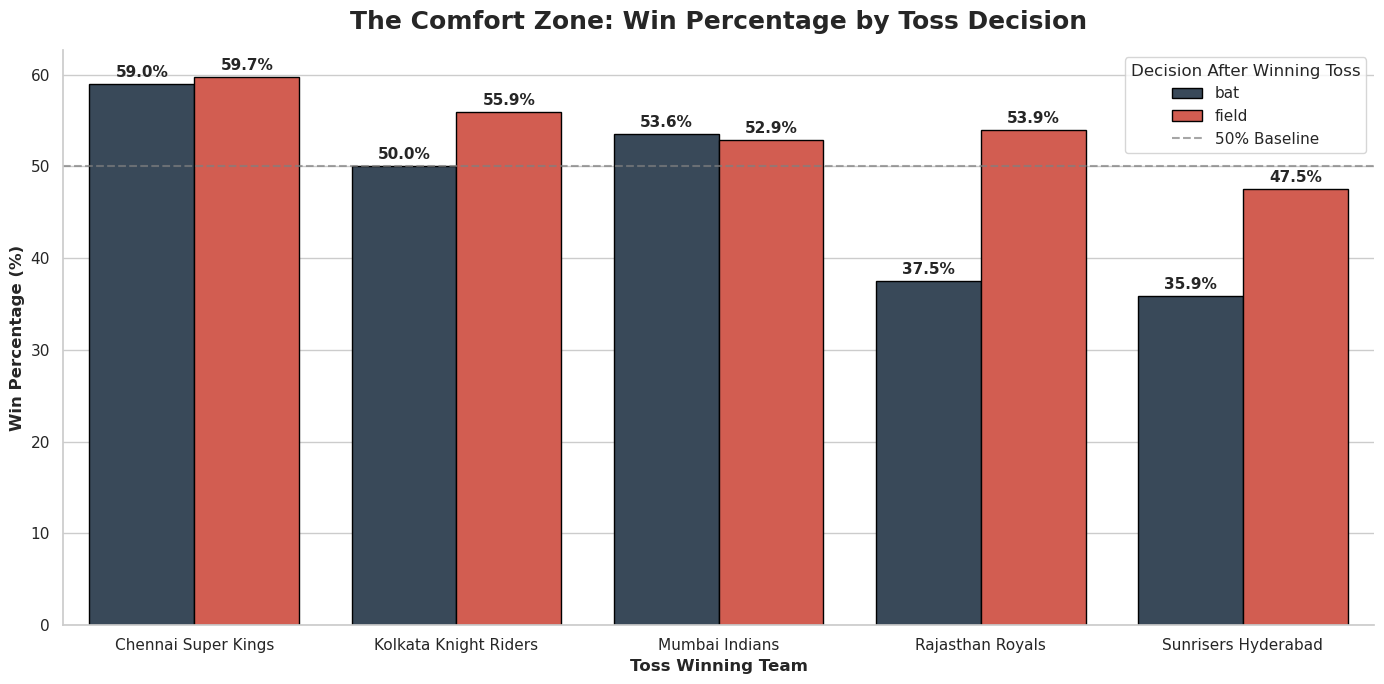

In [9]:
# --- STEP 1: Get Clean Match-Level Data ---
match_df = df.drop_duplicates(subset=['match_id']).copy()

# --- STEP 2: Filter for Major Franchises ---
# We use the most established teams for a clean, historically accurate chart
major_teams = [
    'Chennai Super Kings', 'Mumbai Indians', 'Kolkata Knight Riders', 
    'Royal Challengers Bangalore', 'Rajasthan Royals', 'Sunrisers Hyderabad'
]

# Keep only matches where these specific teams won the toss
toss_data = match_df[match_df['toss_winner'].isin(major_teams)].copy()

# --- STEP 3: The Win Calculation ---
# Create a binary column: 1 if the toss winner won the match, 0 if they lost
toss_data['toss_winner_won'] = (toss_data['toss_winner'] == toss_data['winner']).astype(int)

# Group by the Team and their Decision, then calculate the mean (which gives win percentage)
specialty_stats = toss_data.groupby(['toss_winner', 'toss_decision'])['toss_winner_won'].mean().reset_index()

# Convert decimal to percentage
specialty_stats['win_percentage'] = specialty_stats['toss_winner_won'] * 100

# --- STEP 4: Build the Visualization ---
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=specialty_stats,
    x='toss_winner',
    y='win_percentage',
    hue='toss_decision',
    palette=['#34495e', '#e74c3c'], # Dark Blue for fielding, Red for batting
    edgecolor='black'
)

# Add titles and labels
plt.title('The Comfort Zone: Win Percentage by Toss Decision', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Toss Winning Team', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage (%)', fontsize=12, fontweight='bold')

# Draw a line at 50% to clearly show what is above average and below average
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Baseline')

# Add the exact percentages on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')

plt.legend(title='Decision After Winning Toss')
sns.despine()
plt.tight_layout()
plt.show()

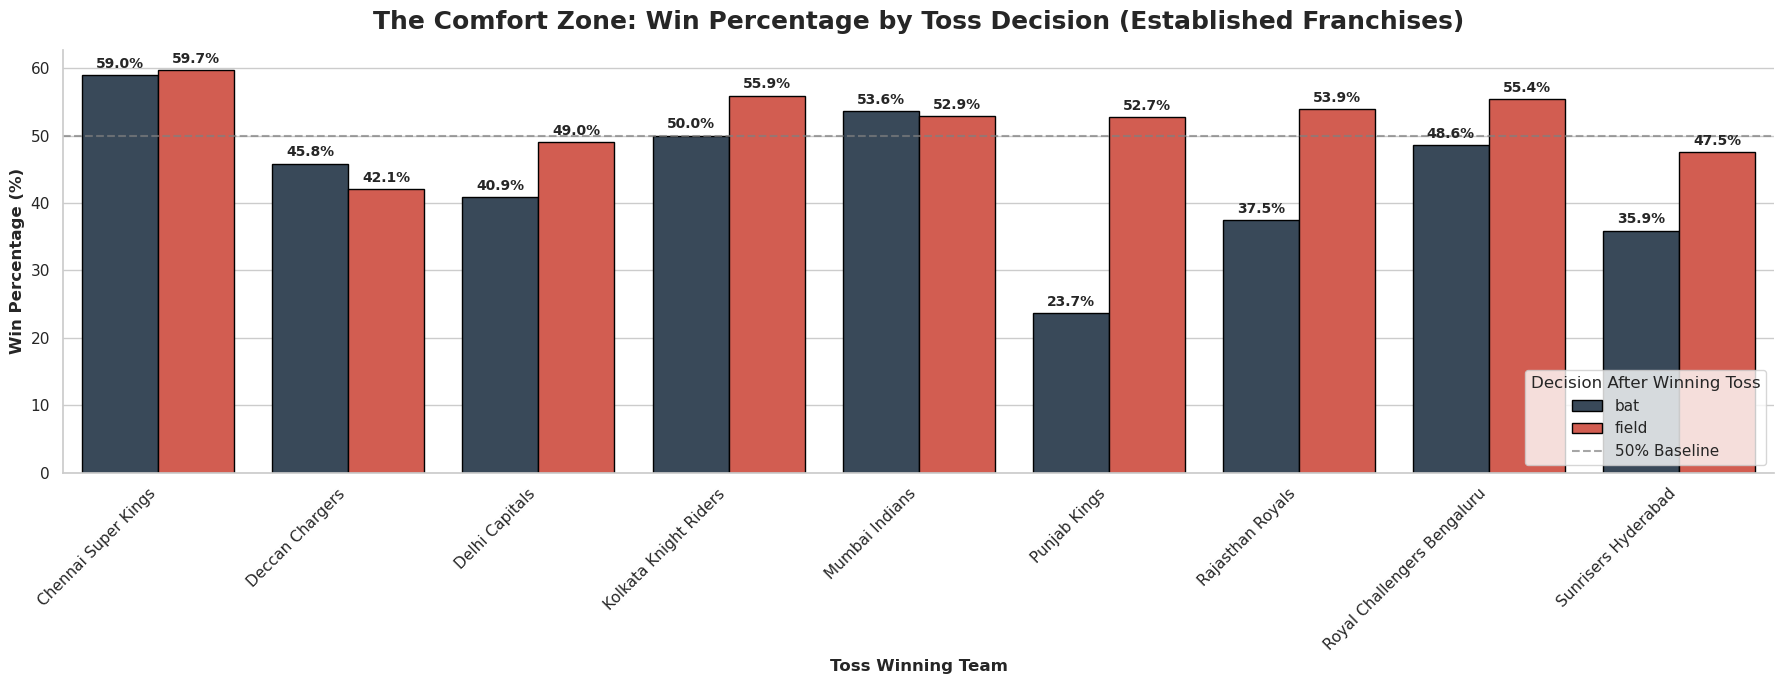

In [10]:
# --- STEP 1: Get Clean Match-Level Data ---
match_df = df.drop_duplicates(subset=['match_id']).copy()

# --- STEP 2: The Dynamic Threshold Filter ---
# Count how many total tosses each franchise has won historically
toss_counts = match_df['toss_winner'].value_counts()

# Create a dynamic list of teams that have won at least 40 tosses
valid_teams = toss_counts[toss_counts >= 40].index

# Filter the dataset to only include those established teams
toss_data = match_df[match_df['toss_winner'].isin(valid_teams)].copy()

# --- STEP 3: The Win Calculation ---
toss_data['toss_winner_won'] = (toss_data['toss_winner'] == toss_data['winner']).astype(int)

specialty_stats = toss_data.groupby(['toss_winner', 'toss_decision'])['toss_winner_won'].mean().reset_index()
specialty_stats['win_percentage'] = specialty_stats['toss_winner_won'] * 100

# --- STEP 4: Build the Expanded Visualization ---
# Increased the width from 14 to 18 to comfortably fit more teams
plt.figure(figsize=(18, 7))

ax = sns.barplot(
    data=specialty_stats,
    x='toss_winner',
    y='win_percentage',
    hue='toss_decision',
    palette=['#34495e', '#e74c3c'], 
    edgecolor='black'
)

plt.title('The Comfort Zone: Win Percentage by Toss Decision (Established Franchises)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Toss Winning Team', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage (%)', fontsize=12, fontweight='bold')
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Baseline')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

# NEW: Rotate the team names on the X-axis by 45 degrees so they don't crash into each other
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.legend(title='Decision After Winning Toss', loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

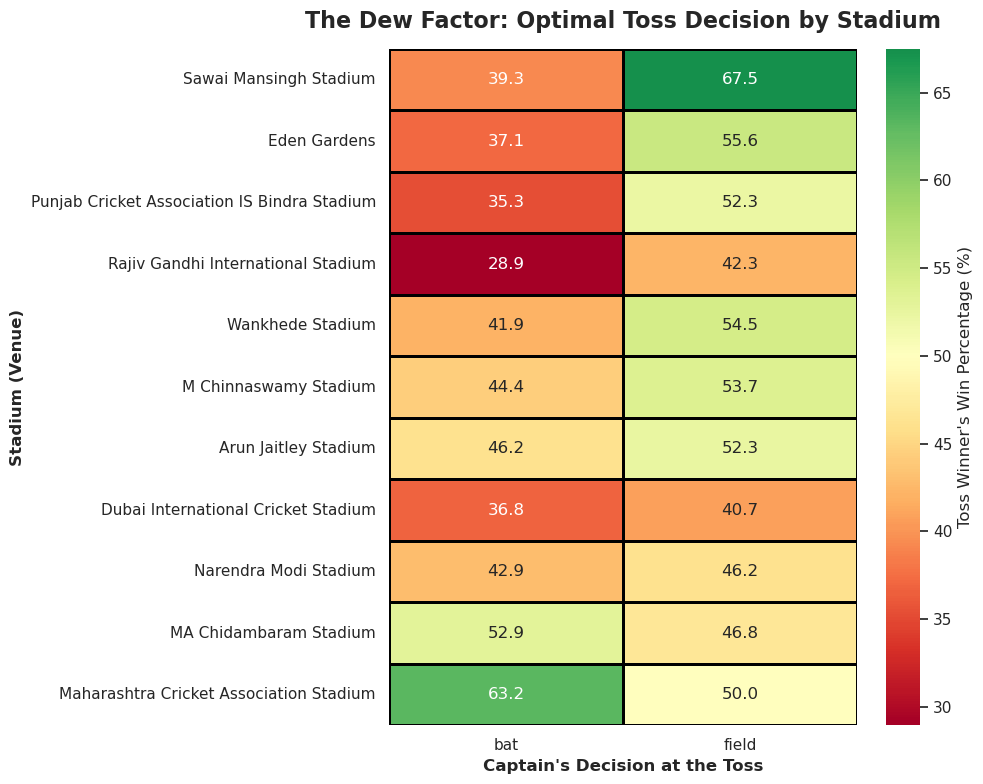

In [11]:
# --- STEP 1: Filter for Established Stadiums ---
# Count matches per venue and only keep stadiums with at least 40 matches
venue_counts = match_df['venue'].value_counts()
top_venues = venue_counts[venue_counts >= 40].index

venue_toss_data = match_df[match_df['venue'].isin(top_venues)].copy()

# --- STEP 2: Calculate the Win Rates ---
# Did the team that won the toss actually win the match?
venue_toss_data['toss_winner_won'] = (venue_toss_data['toss_winner'] == venue_toss_data['winner']).astype(int)

# Group by the Venue AND the Toss Decision
venue_stats = venue_toss_data.groupby(['venue', 'toss_decision'])['toss_winner_won'].mean().reset_index()
venue_stats['win_percentage'] = venue_stats['toss_winner_won'] * 100

# --- STEP 3: Pivot the Data for the Heatmap ---
# This turns 'bat' and 'field' into columns, and 'venue' into rows
heatmap_data = venue_stats.pivot(index='venue', columns='toss_decision', values='win_percentage')

# Advanced Trick: Let's sort the Heatmap logically!
# We calculate the "Chasing Bias" (Field Win % minus Bat Win %) 
# to order the stadiums from "Must Chase" to "Must Defend"
heatmap_data['chasing_bias'] = heatmap_data['field'] - heatmap_data['bat']
heatmap_data = heatmap_data.sort_values('chasing_bias', ascending=False)

# Drop the temporary sorting column so it doesn't show up in the chart
heatmap_data = heatmap_data.drop(columns=['chasing_bias'])

# --- STEP 4: Build the Heatmap ---
plt.figure(figsize=(10, 8))

# We use a Red-Yellow-Green colormap centered exactly at 50%
sns.heatmap(
    heatmap_data, 
    annot=True,          # Write the exact percentage in the boxes
    fmt=".1f",           # Format to 1 decimal place
    cmap="RdYlGn",       # Red = Bad, Yellow = Average, Green = Good
    center=50,           # Force the color scale to treat 50% as the neutral middle
    linewidths=1, 
    linecolor='black',
    cbar_kws={'label': 'Toss Winner\'s Win Percentage (%)'}
)

plt.title('The Dew Factor: Optimal Toss Decision by Stadium', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Captain\'s Decision at the Toss', fontsize=12, fontweight='bold')
plt.ylabel('Stadium (Venue)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_23481/3642493660.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


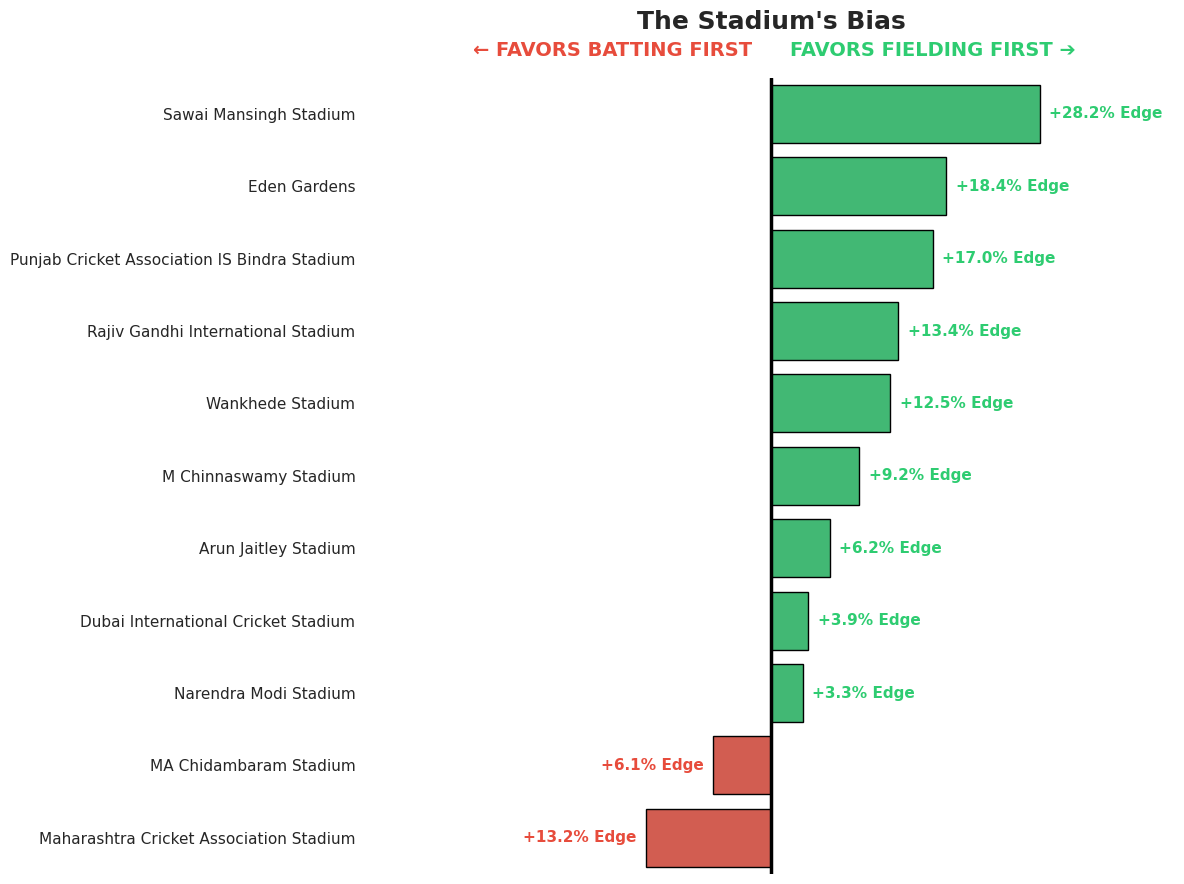

In [12]:
# --- STEP 1: Calculate the Advantage ---
bias_df = heatmap_data.copy().reset_index()

# Positive = Field Advantage, Negative = Bat Advantage
bias_df['chasing_advantage'] = bias_df['field'] - bias_df['bat']
bias_df = bias_df.sort_values('chasing_advantage', ascending=False)

# Assign colors: Green for Fielding, Red for Batting
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in bias_df['chasing_advantage']]


# --- STEP 2: Build the Idiot-Proof Chart ---
plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=bias_df,
    x='chasing_advantage',
    y='venue',
    palette=colors,
    edgecolor='black'
)

# Draw the bold centerline
plt.axvline(0, color='black', linewidth=2.5)

# --- STEP 3: The UX Overhaul ---
# 1. Nuke the confusing X-axis entirely
ax.set_xticks([])
plt.xlabel('')
plt.ylabel('')

# 2. Add Giant "Zone" Headers at the top of the chart
plt.text(2, -0.8, 'FAVORS FIELDING FIRST ➔', color='#2ecc71', fontsize=14, fontweight='bold', ha='left')
plt.text(-2, -0.8, '← FAVORS BATTING FIRST', color='#e74c3c', fontsize=14, fontweight='bold', ha='right')

# 3. Add plain-English text directly to the bars (and fix the previous bug!)
# We iterate through the actual drawn rectangles (patches) to get perfect alignment
for p in ax.patches:
    value = p.get_width()
    
    # If the bar goes right (Fielding)
    if value > 0:
        ax.text(value + 1, p.get_y() + p.get_height()/2, f"+{value:.1f}% Edge", 
                va='center', ha='left', fontsize=11, fontweight='bold', color='#2ecc71')
    # If the bar goes left (Batting)
    elif value < 0:
        ax.text(value - 1, p.get_y() + p.get_height()/2, f"+{abs(value):.1f}% Edge", 
                va='center', ha='right', fontsize=11, fontweight='bold', color='#e74c3c')

# --- STEP 4: Final Formatting ---
plt.title('The Stadium\'s Bias', fontsize=18, fontweight='bold', pad=35)

# Dynamically expand the X-axis bounds so our custom text doesn't get cut off
max_val = bias_df['chasing_advantage'].abs().max()
plt.xlim(-max_val * 1.5, max_val * 1.5)

# Remove all outer borders for a clean dashboard look
sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()

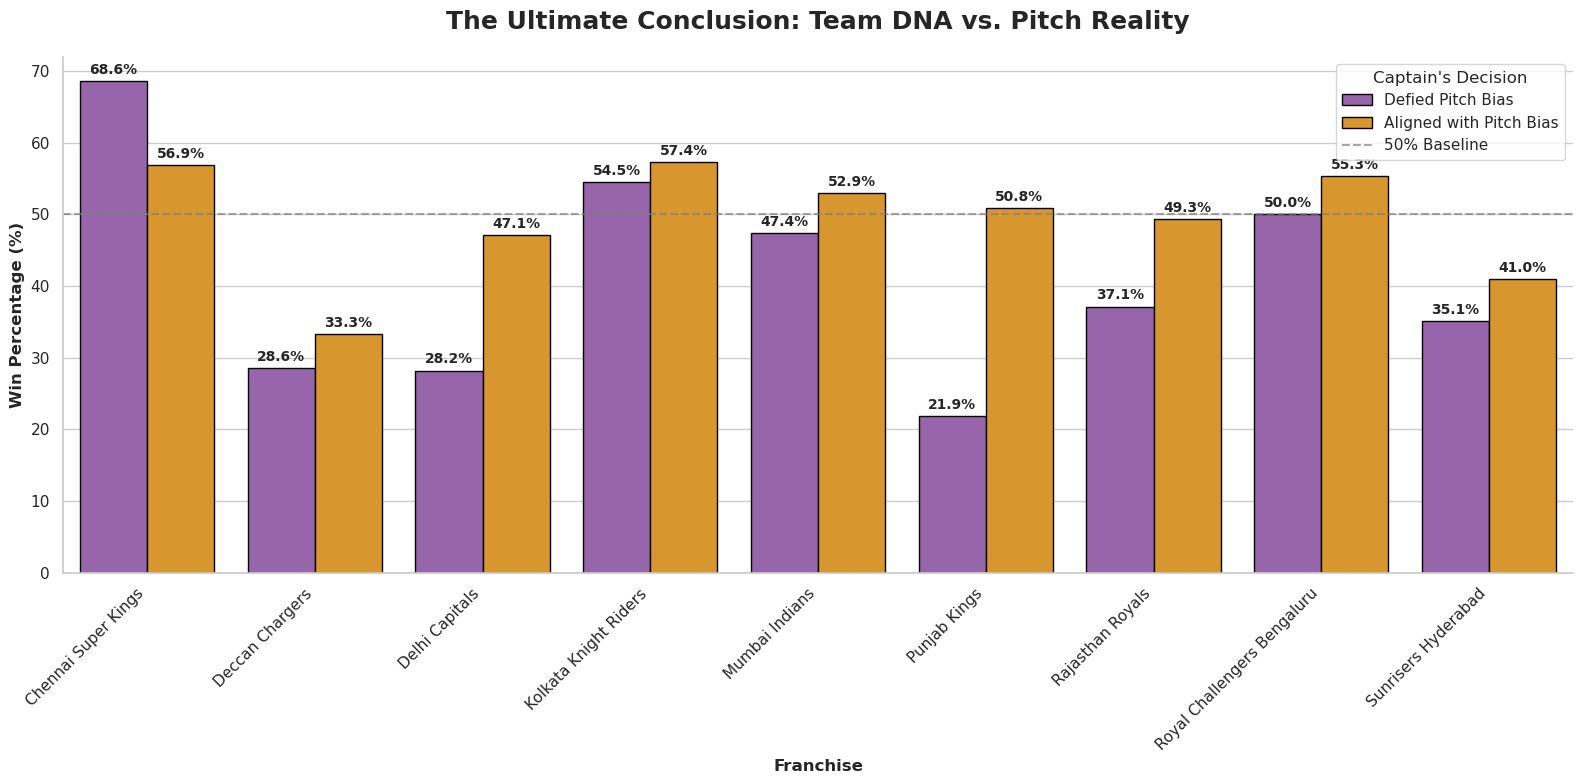

In [13]:
# --- STEP 1: Determine the Pitch's True Bias ---
# We use the heatmap_data from earlier to figure out what the pitch "wants"
pitch_logic = heatmap_data.copy()

# If Field Win % is higher than Bat Win %, the pitch prefers Fielding. Otherwise, Batting.
pitch_logic['pitch_prefers'] = np.where(pitch_logic['field'] > pitch_logic['bat'], 'field', 'bat')

# Create a simple dictionary mapping {Stadium Name: 'field' or 'bat'}
pitch_dictionary = pitch_logic['pitch_prefers'].to_dict()


# --- STEP 2: Map the Bias Back to the Matches ---
# We use the major teams toss_data we created in the first step
aligned_data = toss_data.dropna(subset=['venue']).copy()

# Add a column showing what the mathematically correct decision was for that specific venue
aligned_data['correct_decision'] = aligned_data['venue'].map(pitch_dictionary)

# Drop any rows where the venue wasn't in our top stadiums list
aligned_data = aligned_data.dropna(subset=['correct_decision'])

# Did the captain make the mathematically correct choice? (True/False)
aligned_data['listened_to_pitch'] = aligned_data['toss_decision'] == aligned_data['correct_decision']


# --- STEP 3: Calculate the Ultimate Win Rates ---
# Group by Team and whether they listened to the pitch
alignment_stats = aligned_data.groupby(['toss_winner', 'listened_to_pitch'])['toss_winner_won'].mean().reset_index()
alignment_stats['win_percentage'] = alignment_stats['toss_winner_won'] * 100

# Rename the True/False flags for a cleaner chart legend
alignment_stats['Strategy'] = np.where(
    alignment_stats['listened_to_pitch'], 
    'Aligned with Pitch Bias', 
    'Defied Pitch Bias'
)


# --- STEP 4: Build the Ultimate Visual ---
plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=alignment_stats,
    x='toss_winner',
    y='win_percentage',
    hue='Strategy',
    palette=['#9b59b6', '#f39c12'], # Purple for Aligned, Gold for Defied
    edgecolor='black'
)

plt.title('The Ultimate Conclusion: Team DNA vs. Pitch Reality', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Franchise', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage (%)', fontsize=12, fontweight='bold')

plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Baseline')
plt.xticks(rotation=45, ha='right', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

plt.legend(title='Captain\'s Decision', loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

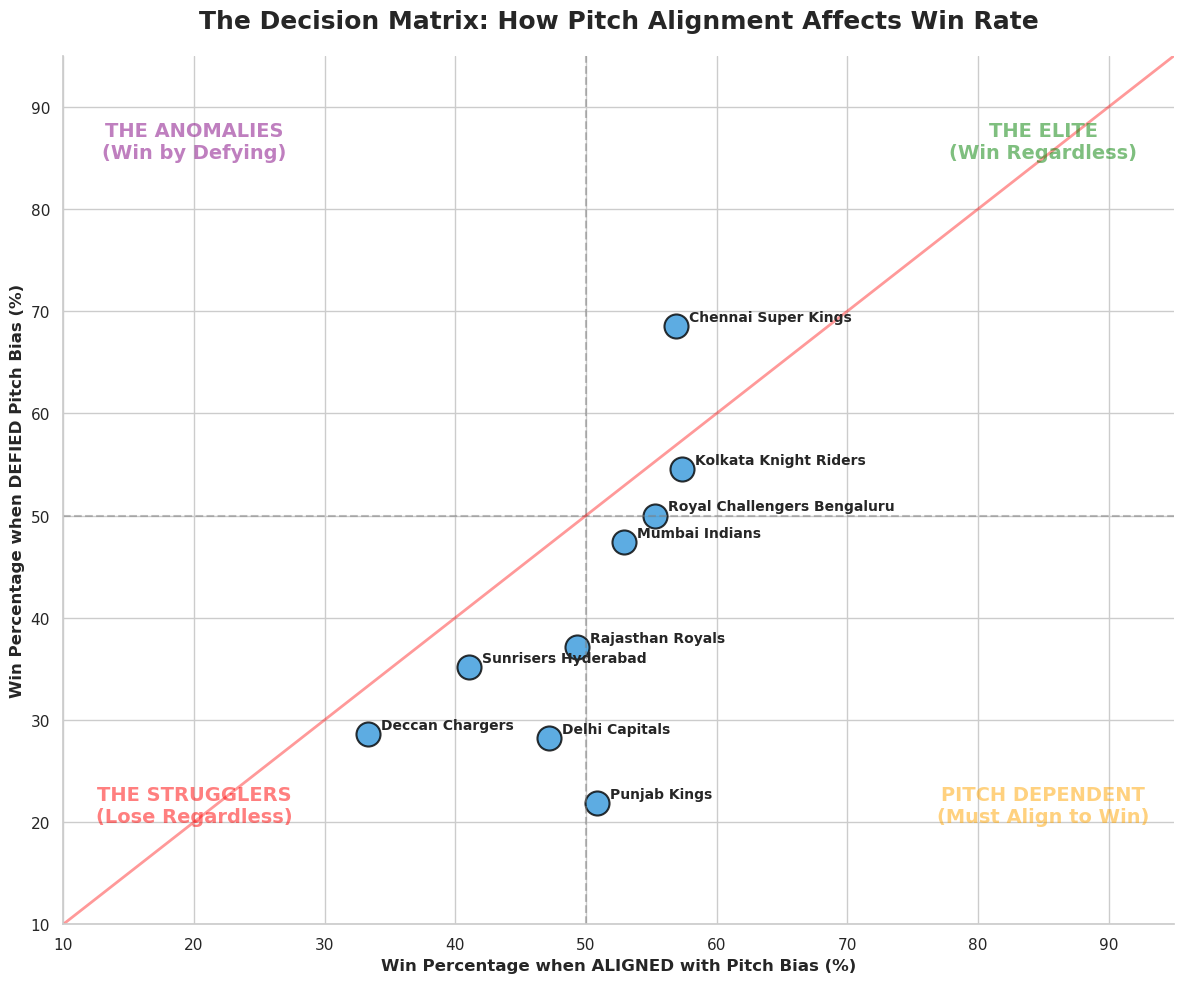

In [14]:
# --- STEP 1: Pivot the Data for the Scatter Plot ---
# We use the alignment_stats from the previous code block
matrix_df = alignment_stats.pivot(
    index='toss_winner', 
    columns='Strategy', 
    values='win_percentage'
).reset_index()

# Clean up column names for easier referencing
matrix_df.columns.name = None
matrix_df = matrix_df.rename(columns={
    'Aligned with Pitch Bias': 'Aligned_Win',
    'Defied Pitch Bias': 'Defied_Win'
})

# Drop any teams that might not have data for both scenarios (to prevent plotting errors)
matrix_df = matrix_df.dropna()


# --- STEP 2: Build the Scatter Plot Matrix ---
plt.figure(figsize=(12, 10))

# Draw the dots
sns.scatterplot(
    data=matrix_df,
    x='Aligned_Win',
    y='Defied_Win',
    s=300,            # Make the dots massive
    color='#3498db',  # Nice professional blue
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

# --- STEP 3: Draw the Analytical Lines ---
# 1. The 50% Baselines (Creates the 4 Quadrants)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5)
plt.axhline(50, color='gray', linestyle='--', alpha=0.5)

# 2. The Diagonal "Line of Neutrality" (Where Aligned == Defied)
# Teams on this line win at the exact same rate regardless of their decision
plt.plot([0, 100], [0, 100], color='red', linestyle='-', alpha=0.4, linewidth=2)


# --- STEP 4: Annotate the Teams and Quadrants ---
# Automatically write the franchise name next to every dot
for i, row in matrix_df.iterrows():
    plt.text(
        row['Aligned_Win'] + 1,    # Nudge text slightly right
        row['Defied_Win'] + 0.5,   # Nudge text slightly up
        row['toss_winner'], 
        fontsize=10, 
        fontweight='bold'
    )

# Add "Zone" text to explain the quadrants to the viewer
plt.text(85, 85, 'THE ELITE\n(Win Regardless)', color='green', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(85, 20, 'PITCH DEPENDENT\n(Must Align to Win)', color='orange', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(20, 20, 'THE STRUGGLERS\n(Lose Regardless)', color='red', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(20, 85, 'THE ANOMALIES\n(Win by Defying)', color='purple', fontsize=14, fontweight='bold', alpha=0.5, ha='center')

# --- STEP 5: Final Beautification ---
plt.title('The Decision Matrix: How Pitch Alignment Affects Win Rate', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Win Percentage when ALIGNED with Pitch Bias (%)', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage when DEFIED Pitch Bias (%)', fontsize=12, fontweight='bold')

# Set strict limits so the chart is a perfect square grid
plt.xlim(10, 95)
plt.ylim(10, 95)

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_26164/856542511.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


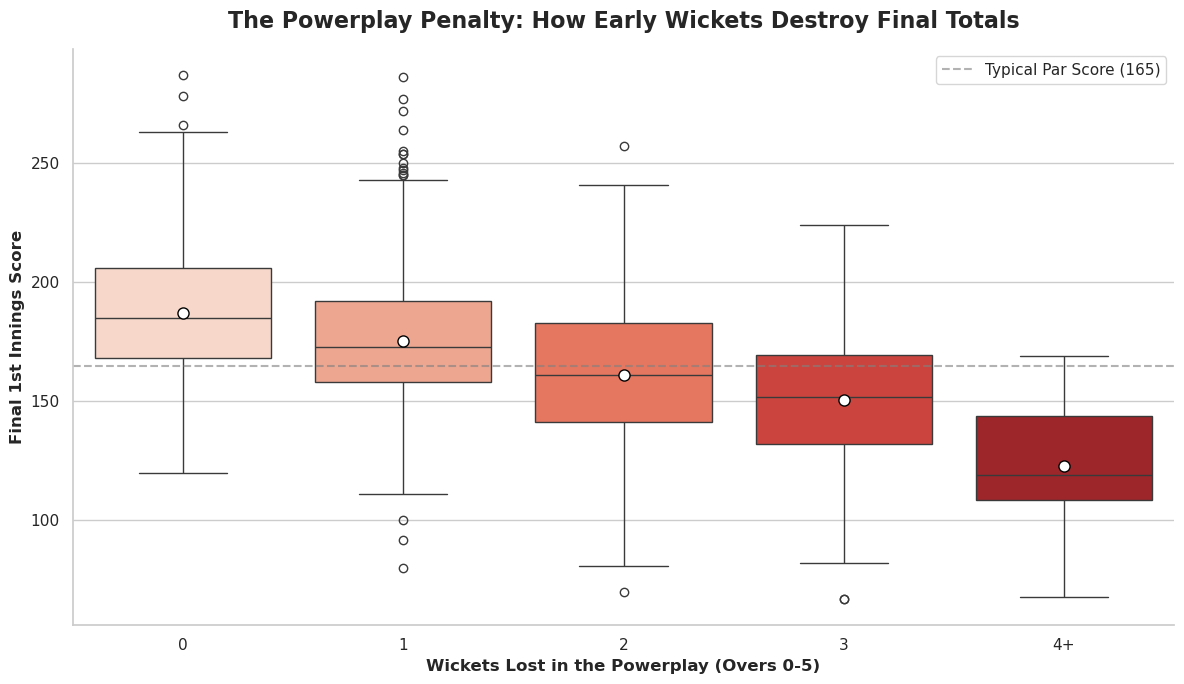

In [9]:
# --- STEP 1: Isolate 1st Innings Data ---
# We only use 1st innings because 2nd innings scores are artificially capped by the target
inn1_df = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()

# --- STEP 2: Calculate Final Scores ---
# Find the maximum score reached in every 1st innings
final_scores = inn1_df.groupby('match_id')['current_score'].max().reset_index()
final_scores.rename(columns={'current_score': 'final_total'}, inplace=True)

# --- STEP 3: Count Powerplay Wickets ---
# Filter for just the Powerplay
pp_data = inn1_df[inn1_df['phase'] == 'Powerplay']

# Sum the wickets per match in this phase
pp_wickets = pp_data.groupby('match_id')['is_wicket'].sum().reset_index()
pp_wickets.rename(columns={'is_wicket': 'pp_wickets_lost'}, inplace=True)

# --- STEP 4: Merge and Clean ---
# Combine the wickets lost with the final total
damage_df = pd.merge(final_scores, pp_wickets, on='match_id', how='left')

# Fill NaNs with 0 (in case a team lost 0 wickets in the PP)
damage_df['pp_wickets_lost'] = damage_df['pp_wickets_lost'].fillna(0).astype(int)

# Group 4+ wickets together because 5 or 6 wickets is rare and skews the chart
damage_df['pp_wickets_grouped'] = damage_df['pp_wickets_lost'].apply(lambda x: '4+' if x >= 4 else str(x))

# --- STEP 5: Build the Visualization ---
plt.figure(figsize=(12, 7))

# A Box Plot shows the median, the typical range, and the outliers
sns.boxplot(
    data=damage_df.sort_values('pp_wickets_grouped'),
    x='pp_wickets_grouped',
    y='final_total',
    palette='Reds', # Starts light red (0 wickets) goes to dark red (4+ wickets)
    showmeans=True, # Adds a marker for the mathematical average
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title('The Powerplay Penalty: How Early Wickets Destroy Final Totals', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Wickets Lost in the Powerplay (Overs 0-5)', fontsize=12, fontweight='bold')
plt.ylabel('Final 1st Innings Score', fontsize=12, fontweight='bold')

# Draw a baseline reference (e.g., a "par" score of 165)
plt.axhline(165, color='gray', linestyle='--', alpha=0.6, label='Typical Par Score (165)')

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

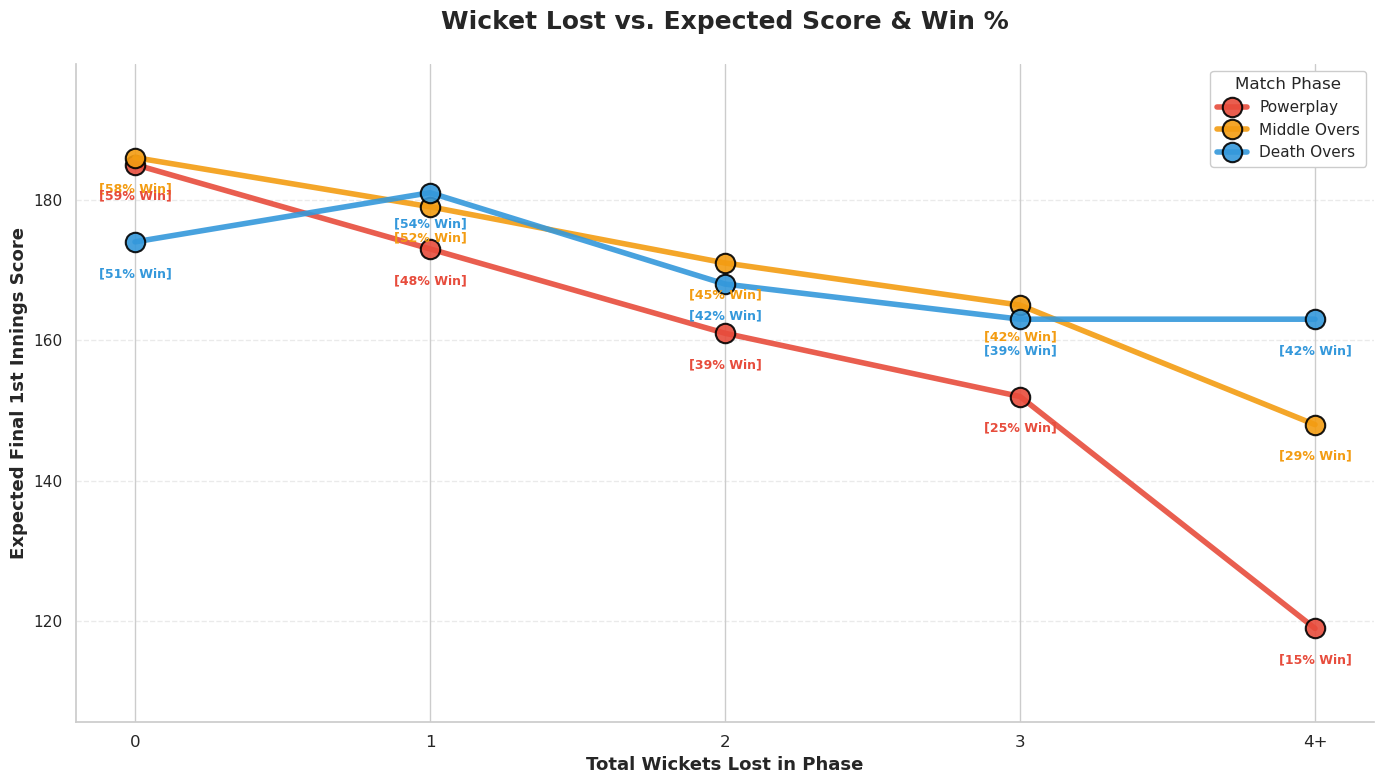

In [21]:
# --- STEP 1: Add Win/Loss Data to the Match Summaries ---
inn1_df = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()
phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}
# Create a flag for whether the team batting first actually won the match
# (Note: make sure 'batting_team' matches your exact column name)
inn1_df['bat_first_won'] = (inn1_df['batting_team'] == inn1_df['winner']).astype(int)

# Get final score AND win status for every match
match_summaries = inn1_df.groupby('match_id').agg(
    final_total=('current_score', 'max'),
    bat_first_won=('bat_first_won', 'max') # Status is the same for the whole match
).reset_index()

# Get wickets lost per phase
phase_wickets = inn1_df.groupby(['match_id', 'phase'])['is_wicket'].sum().unstack(fill_value=0).reset_index()
master_df = pd.merge(match_summaries, phase_wickets, on='match_id')

# --- STEP 2: Melt and Cap Wickets ---
melted_df = master_df.melt(
    id_vars=['match_id', 'final_total', 'bat_first_won'], 
    value_vars=['Powerplay', 'Middle Overs', 'Death Overs'], 
    var_name='Phase', 
    value_name='Wickets_Lost'
)
melted_df['Wickets_Lost'] = melted_df['Wickets_Lost'].apply(lambda x: 4 if x >= 4 else x)

# --- STEP 3: Calculate Both Medians and Win Rates ---
curve_df = melted_df.groupby(['Phase', 'Wickets_Lost']).agg(
    expected_score=('final_total', 'median'),
    win_rate=('bat_first_won', 'mean')
).reset_index()

# Convert win rate to a readable percentage
curve_df['win_percentage'] = curve_df['win_rate'] * 100


# --- STEP 4: Build the Visual ---
plt.figure(figsize=(14, 8))



# Draw the core trajectory lines
ax = sns.lineplot(
    data=curve_df,
    x='Wickets_Lost',
    y='expected_score',
    hue='Phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,           
    marker='o',            
    markersize=14,         
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9
)

# --- STEP 5: The Dual-Annotation Masterstroke ---
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['Phase']]
    # 2. Print the Win Probability BELOW the dot (Grey, slightly smaller)
    plt.text(

        row['Wickets_Lost'], 
        row['expected_score'] - 5, # Nudge DOWN
        f"[{row['win_percentage']:.0f}% Win]", 
        color=text_color, 
        ha='center', 
        fontsize=9, 
        fontweight='bold'
    )

# --- STEP 6: Professional Formatting ---
plt.title('Wicket Lost vs. Expected Score & Win %', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total Wickets Lost in Phase', fontsize=13, fontweight='bold')
plt.ylabel('Expected Final 1st Innings Score', fontsize=13, fontweight='bold')

plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['0', '1', '2', '3', '4+'], fontsize=12)

# Expand the Y-axis slightly so our text annotations don't get cut off at the top/bottom
current_ylim = plt.ylim()
plt.ylim(current_ylim[0] - 10, current_ylim[1] + 10)

plt.legend(title='Match Phase', loc='upper right', fontsize=11, title_fontsize=12, framealpha=1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_26164/2976488580.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_df = toxicity_df.groupby(['phase', 'pressure_level']).agg(


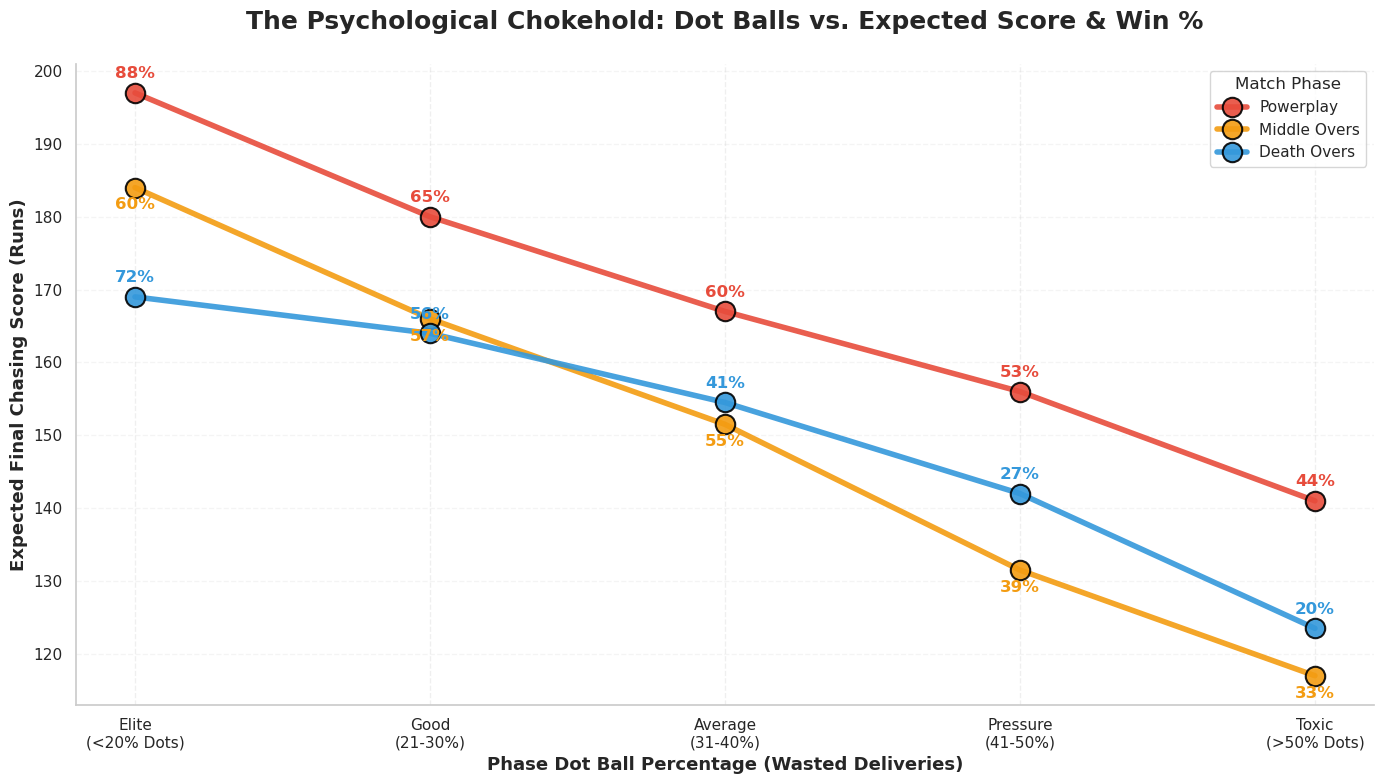

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Isolate Run Chases (2nd Innings) ---
inn2_df = df[(df['innings'] == 2) & (df['is_rain_reduced']==0)].copy()

# Define a dot ball (Assuming 'runs_total' being 0 captures no runs scored)
inn2_df['is_dot'] = (inn2_df['runs_total'] == 0).astype(int)

# --- STEP 2: Calculate Dot Percentage & Final Scores per Match ---
# 1. Get the dot ball stats
phase_stats = inn2_df.groupby(['match_id', 'phase']).agg(
    dot_balls=('is_dot', 'sum'),
    total_balls=('ball', 'count') # Count total deliveries in that phase
).reset_index()
phase_stats['dot_percentage'] = (phase_stats['dot_balls'] / phase_stats['total_balls']) * 100

# 2. Get the final score of the run chase
final_scores = inn2_df.groupby('match_id')['current_score'].max().reset_index(name='final_total')

# --- STEP 3: Create the 'Pressure Buckets' ---
bins = [-1, 20, 30, 40, 50, 101]
labels = ['Elite\n(<20% Dots)', 'Good\n(21-30%)', 'Average\n(31-40%)', 'Pressure\n(41-50%)', 'Toxic\n(>50% Dots)']
phase_stats['pressure_level'] = pd.cut(phase_stats['dot_percentage'], bins=bins, labels=labels)

# --- STEP 4: Map Outcomes & Aggregate Both Metrics ---
# Did the chasing team win the match?
match_outcomes = inn2_df.groupby('match_id').apply(
    lambda x: 1 if x['batting_team'].iloc[0] == x['winner'].iloc[0] else 0
).reset_index(name='chasing_team_won')

# Merge stats, outcomes, and final scores into one master frame
toxicity_df = pd.merge(phase_stats, match_outcomes, on='match_id')
toxicity_df = pd.merge(toxicity_df, final_scores, on='match_id')

# Aggregate BOTH the median expected score (Y-Axis) and the win percentage (Text)
curve_df = toxicity_df.groupby(['phase', 'pressure_level']).agg(
    expected_score=('final_total', 'median'),
    win_rate=('chasing_team_won', 'mean')
).reset_index()

curve_df['win_percentage'] = curve_df['win_rate'] * 100
curve_df = curve_df.dropna()


# --- STEP 5: Build the Dual-Metric Visual ---
plt.figure(figsize=(14, 8))

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Draw the pressure trajectory lines using EXPECTED SCORE
ax = sns.lineplot(
    data=curve_df,
    x='pressure_level',
    y='expected_score', # Changed to plot physical runs
    hue='phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,
    marker='o',
    markersize=14,
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9
)

# --- STEP 6: Color-Coded UX Annotations (Win Percentage) ---
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['phase']]
    
    # Dynamic offset mapped to "runs" scale (so text sits above/below the dot)
    y_offset = 2 if row['phase'] != 'Middle Overs' else -3
    
    plt.text(
        row['pressure_level'], 
        row['expected_score'] + y_offset, # Anchored to the expected score coordinate
        f"{int(row['win_percentage'])}%", # Displaying the Win Percentage
        color=text_color, 
        ha='center', 
        fontsize=12, 
        fontweight='bold'
    )

# --- STEP 7: Professional Formatting ---
plt.title('The Psychological Chokehold: Dot Balls vs. Expected Score & Win %', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Phase Dot Ball Percentage (Wasted Deliveries)', fontsize=13, fontweight='bold')
plt.ylabel('Expected Final Chasing Score (Runs)', fontsize=13, fontweight='bold') # Updated label

# Format grids
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.legend(title='Match Phase', loc='upper right', fontsize=11, title_fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_26164/1391552635.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_df = sr_df.groupby(['phase', 'sr_bucket']).agg(


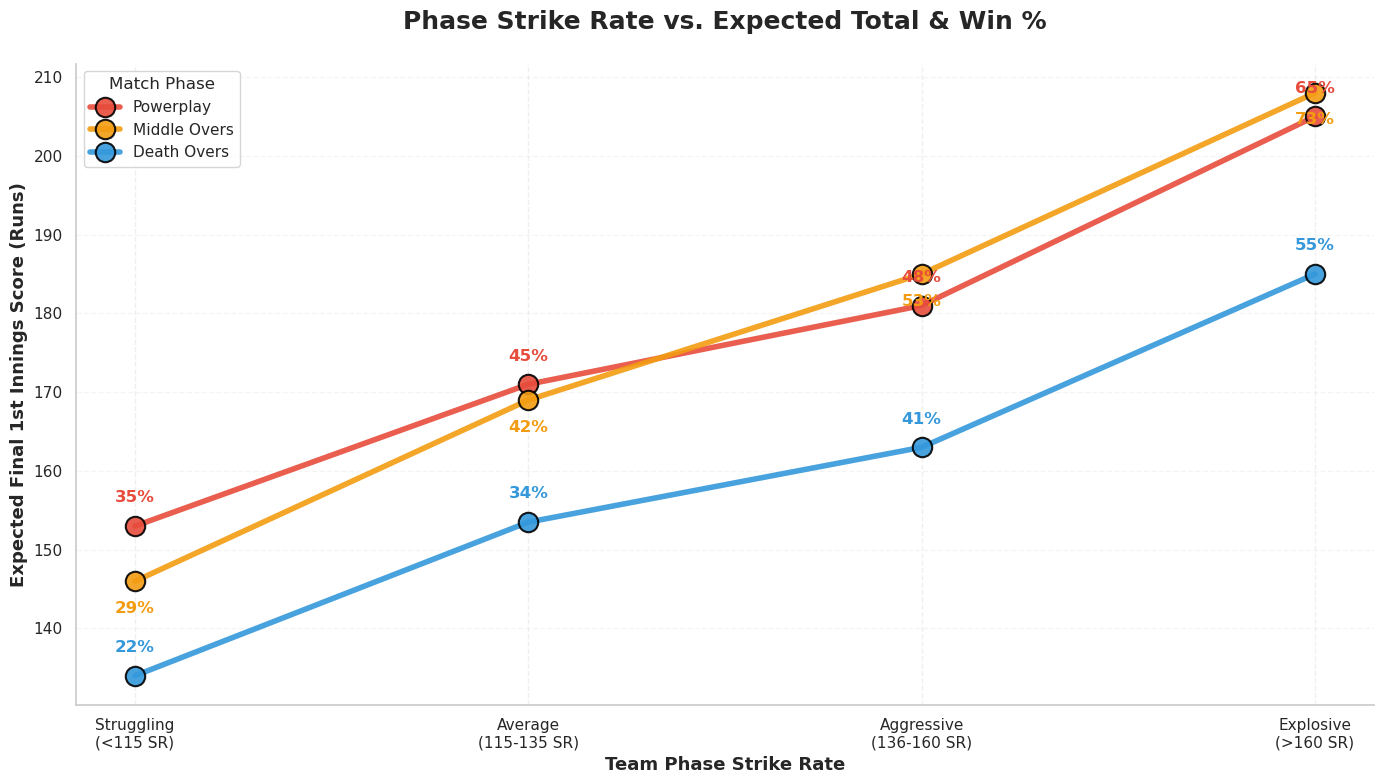

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Isolate 1st Innings ---
inn1_df = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()

# --- STEP 2: Calculate Strike Rate per Match AND Phase ---
# We want to exclude wides from the ball count to get a true Strike Rate
valid_balls_df = inn1_df[inn1_df['extras_wides'].isna() | (inn1_df['extras_wides'] == 0)]

# Aggregate runs and balls per phase
phase_stats = valid_balls_df.groupby(['match_id', 'phase']).agg(
    phase_runs=('runs_batter', 'sum'),
    phase_balls=('ball', 'count')
).reset_index()

# Calculate Phase Strike Rate
phase_stats['strike_rate'] = (phase_stats['phase_runs'] / phase_stats['phase_balls']) * 100

# --- STEP 3: Create Universal 'Strike Rate Buckets' ---
# We expand the buckets to accommodate both the slower Middle Overs and the explosive Death Overs
bins = [-1, 115, 135, 160, 1000]
labels = ['Struggling\n(<115 SR)', 'Average\n(115-135 SR)', 'Aggressive\n(136-160 SR)', 'Explosive\n(>160 SR)']
phase_stats['sr_bucket'] = pd.cut(phase_stats['strike_rate'], bins=bins, labels=labels)

# --- STEP 4: Get Final Scores and Match Outcomes ---
final_scores = inn1_df.groupby('match_id')['current_score'].max().reset_index(name='final_total')

match_outcomes = inn1_df.groupby('match_id').apply(
    lambda x: 1 if x['batting_team'].iloc[0] == x['winner'].iloc[0] else 0
).reset_index(name='bat_first_won')

# Merge everything
sr_df = pd.merge(phase_stats, final_scores, on='match_id')
sr_df = pd.merge(sr_df, match_outcomes, on='match_id')

# --- STEP 5: Aggregate the Dual Metrics ---
curve_df = sr_df.groupby(['phase', 'sr_bucket']).agg(
    expected_score=('final_total', 'median'),
    win_rate=('bat_first_won', 'mean')
).reset_index()

curve_df['win_percentage'] = curve_df['win_rate'] * 100
curve_df = curve_df.dropna()

# --- STEP 6: Build the 3-Line Visual ---
plt.figure(figsize=(14, 8))

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Draw the lines for Expected Score (Physical Runs)
ax = sns.lineplot(
    data=curve_df,
    x='sr_bucket',
    y='expected_score',
    hue='phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,
    marker='o',
    markersize=14,
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9
)

# Add the Win Percentage Annotations
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['phase']]
    
    # Dynamic offset so text doesn't overlap if the dots get close
    y_offset = 3 if row['phase'] != 'Middle Overs' else -4
    
    plt.text(
        row['sr_bucket'], 
        row['expected_score'] + y_offset, 
        f"{int(row['win_percentage'])}%", 
        color=text_color, 
        ha='center', 
        fontsize=12, 
        fontweight='bold'
    )

# --- STEP 7: Professional Formatting ---
plt.title('Phase Strike Rate vs. Expected Total & Win %', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Team Phase Strike Rate', fontsize=13, fontweight='bold')
plt.ylabel('Expected Final 1st Innings Score (Runs)', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.legend(title='Match Phase', loc='upper left', fontsize=11, title_fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

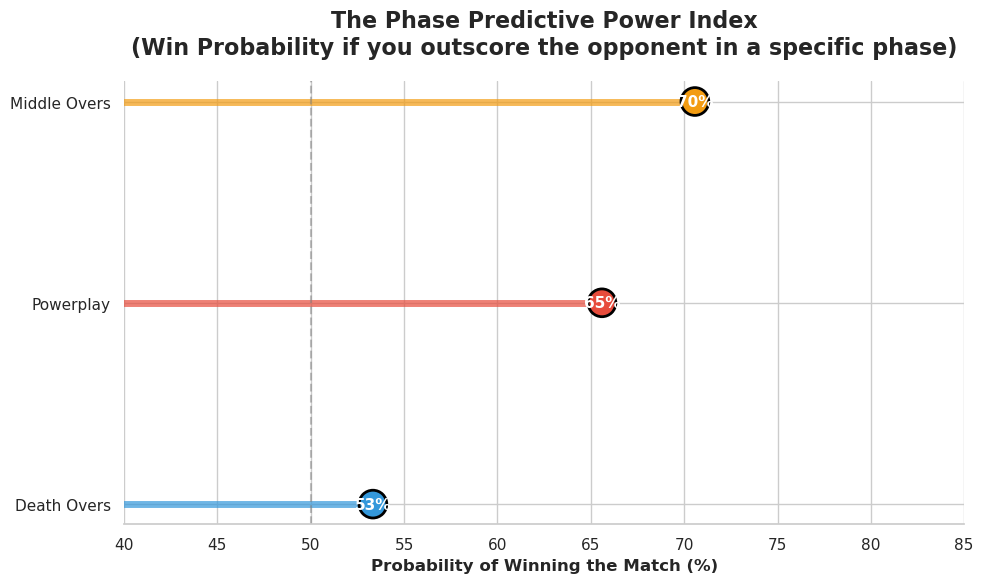

In [14]:
# --- STEP 1: Calculate Runs per Phase for Both Teams ---
# Group the dataset by Match, Phase, and Inning to get total runs scored
df = df[df['is_rain_reduced']==0]
phase_runs = df.groupby(['match_id', 'phase', 'innings'])['runs_total'].sum().reset_index()

# Pivot the data so Inning 1 and Inning 2 are side-by-side
phase_pivot = phase_runs.pivot(
    index=['match_id', 'phase'], 
    columns='innings', 
    values='runs_total'
).reset_index()

# Rename columns for clarity (Inning 1 = Team batting first, Inning 2 = Chasing team)
phase_pivot.columns.name = None
phase_pivot = phase_pivot.rename(columns={1: 'inn1_runs', 2: 'inn2_runs'})

# --- STEP 2: Determine the "Phase Winner" ---
# If Inn1 runs > Inn2 runs, Team 1 won the phase. Otherwise, Team 2 won it.
# (We drop exact ties to keep the probability clean)
phase_pivot = phase_pivot.dropna()
phase_pivot = phase_pivot[phase_pivot['inn1_runs'] != phase_pivot['inn2_runs']]

phase_pivot['phase_winner_inning'] = np.where(
    phase_pivot['inn1_runs'] > phase_pivot['inn2_runs'], 
    1, 
    2
)

# --- STEP 3: Check if the Phase Winner won the Match ---
# Get the match outcome (Did the team batting first win?)
# We use the match_summaries logic from earlier
match_outcomes = df[df['innings'] == 1].groupby('match_id').apply(
    lambda x: 1 if x['batting_team'].iloc[0] == x['winner'].iloc[0] else 2
).reset_index(name='match_winner_inning')

# Merge outcomes with our phase data
predictive_df = pd.merge(phase_pivot, match_outcomes, on='match_id')

# Did the team that won the phase also win the match?
predictive_df['predicted_match_winner'] = (predictive_df['phase_winner_inning'] == predictive_df['match_winner_inning']).astype(int)

# Calculate the final predictive win percentage for each phase
power_index = predictive_df.groupby('phase')['predicted_match_winner'].mean().reset_index()
power_index['predictive_win_rate'] = power_index['predicted_match_winner'] * 100

# Sort from most important to least important
power_index = power_index.sort_values('predictive_win_rate', ascending=True)


# --- STEP 4: Build the Lollipop Chart ---
plt.figure(figsize=(10, 6))

# Define colors based on the phases we used earlier
color_map = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}
colors = power_index['phase'].map(color_map).tolist()

# 1. Draw the "Sticks" (Horizontal lines)
plt.hlines(
    y=power_index['phase'], 
    xmin=0, 
    xmax=power_index['predictive_win_rate'], 
    color=colors, 
    linewidth=5, 
    alpha=0.7
)

# 2. Draw the "Lollipops" (The Scatter Dots at the end)
plt.scatter(
    power_index['predictive_win_rate'], 
    power_index['phase'], 
    color=colors, 
    s=400, # Massive dots
    edgecolor='black', 
    linewidth=2, 
    zorder=3
)

# --- STEP 5: Annotate the Data ---
# Add the exact percentage inside the dots!
for i, row in power_index.iterrows():
    plt.text(
        row['predictive_win_rate'], 
        row['phase'], 
        f"{int(row['predictive_win_rate'])}%", 
        color='white', 
        ha='center', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        zorder=4
    )

# --- STEP 6: Professional Formatting ---
plt.title('The Phase Predictive Power Index\n(Win Probability if you outscore the opponent in a specific phase)', 
          fontsize=16, fontweight='bold', pad=20, ha='center')
plt.xlabel('Probability of Winning the Match (%)', fontsize=12, fontweight='bold')
plt.ylabel('')

# Set X-axis limits to zoom in on the important variance (e.g., 40% to 80%)
plt.xlim(40, 85)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% (Coin Flip)')

sns.despine(left=True)
plt.tight_layout()
plt.show()

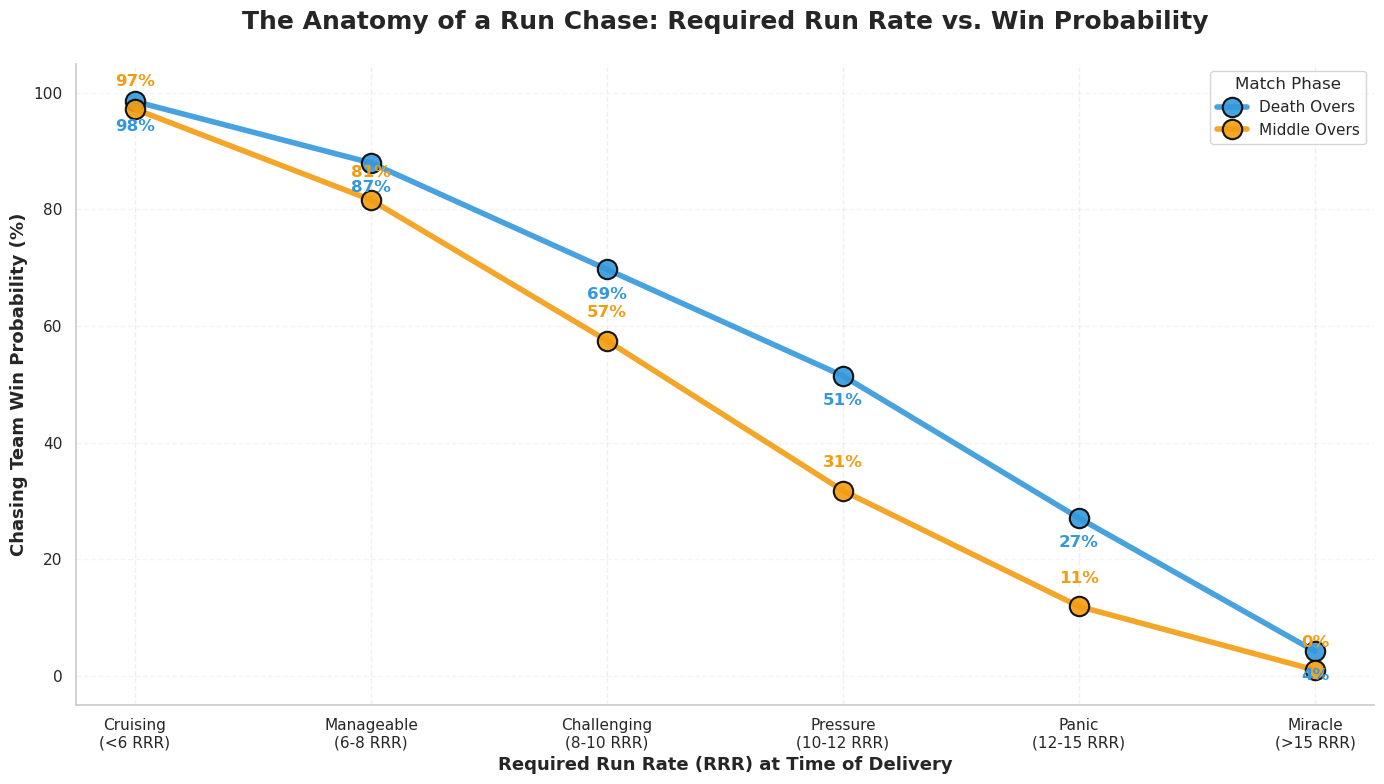

In [20]:
# --- STEP 1: Isolate 2nd Innings & Clean Data ---
# Keep only standard 2nd innings (no rain-reduced matches)
inn2_df = df[(df['innings'] == 2) & (df['is_rain_reduced'] == 0)].copy()

# Drop rows where we have no runs needed or balls remaining (e.g., the final winning ball)
inn2_df = inn2_df.dropna(subset=['runs_needed', 'balls_remaining'])
inn2_df = inn2_df[inn2_df['balls_remaining'] > 0] # Avoid division by zero

# --- STEP 2: Calculate the Pressure Metric (RRR) ---
# Required Run Rate = (Runs Needed / Balls Remaining) * 6 balls
inn2_df['required_run_rate'] = (inn2_df['runs_needed'] / inn2_df['balls_remaining']) * 6

# Create logical RRR Buckets
bins = [-np.inf, 6, 8, 10, 12, 15, np.inf]
labels = ['Cruising\n(<6 RRR)', 'Manageable\n(6-8 RRR)', 'Challenging\n(8-10 RRR)', 'Pressure\n(10-12 RRR)', 'Panic\n(12-15 RRR)', 'Miracle\n(>15 RRR)']
inn2_df['rrr_bucket'] = pd.cut(inn2_df['required_run_rate'], bins=bins, labels=labels)

# --- STEP 3: Match Outcomes ---
# Did the chasing team (batting_team) win?
inn2_df['chasing_team_won'] = np.where(inn2_df['batting_team'] == inn2_df['winner'], 1, 0)

# --- STEP 4: Focus on the Second Half of the Chase ---
# The Powerplay doesn't usually reflect true chase pressure. 
# We want to compare the Middle Overs (Overs 6-14) vs Death Overs (Overs 15-20)
pressure_df = inn2_df[inn2_df['phase'].isin(['Middle Overs', 'Death Overs'])].copy()

# Calculate Win Percentage for each Phase + RRR Bucket combination
chase_curve = pressure_df.groupby(['phase', 'rrr_bucket'], observed=False)['chasing_team_won'].mean().reset_index()
chase_curve['win_percentage'] = chase_curve['chasing_team_won'] * 100
chase_curve = chase_curve.dropna()


# --- STEP 5: Build the Run Chase Pressure Curve ---
fig, ax = plt.subplots(figsize=(14, 8))

phase_colors = {'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Draw the lines
sns.lineplot(
    data=chase_curve,
    x='rrr_bucket',
    y='win_percentage',
    hue='phase',
    palette=phase_colors,
    linewidth=4,
    marker='o',
    markersize=14,
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9,
    ax=ax
)

# Add the specific Win Percentage Annotations
for i, row in chase_curve.iterrows():
    # Only annotate if there's actual data to avoid clutter
    if pd.notna(row['win_percentage']):
        y_offset = 4 if row['phase'] == 'Middle Overs' else -5
        
        ax.text(
            row['rrr_bucket'], 
            row['win_percentage'] + y_offset, 
            f"{int(row['win_percentage'])}%", 
            color=phase_colors[row['phase']], 
            ha='center', 
            fontsize=12, 
            fontweight='bold'
        )

# --- STEP 6: Professional Formatting ---
plt.title('The Anatomy of a Run Chase: Required Run Rate vs. Win Probability', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Required Run Rate (RRR) at Time of Delivery', fontsize=13, fontweight='bold')
plt.ylabel('Chasing Team Win Probability (%)', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.2)

# Set Y-axis from 0 to 105 so the top text labels don't get cut off
plt.ylim(-5, 105)

ax.legend(title='Match Phase', loc='upper right', fontsize=11, title_fontsize=12)
sns.despine()

plt.tight_layout()

# --- STEP 7: Display ---
plt.show()

In [22]:
# Get a sorted list of all the distinct seasons
season_list = sorted(df['season'].unique())
print("The seasons included are:")
print(season_list)

The seasons included are:
[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


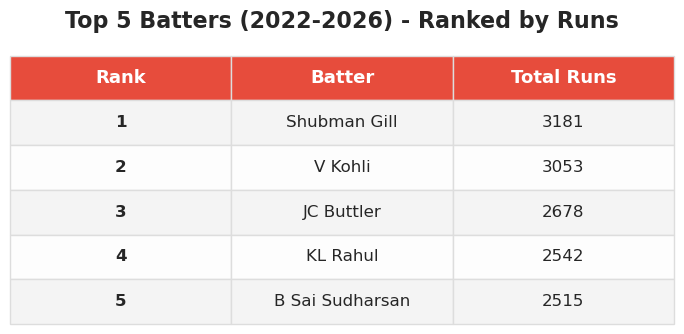

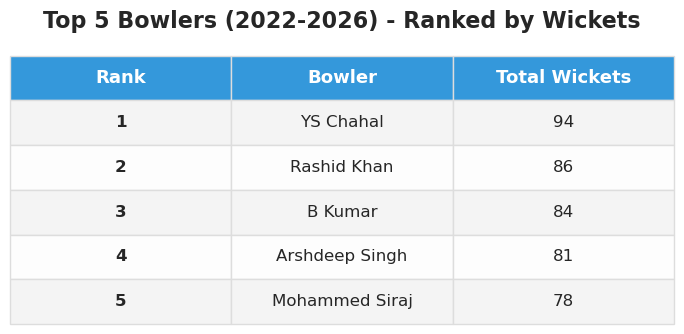

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Filter for the Modern Era (2022-2026) ---
target_seasons = ['2022', '2023', '2024', '2025','2026', 2022, 2023, 2024, 2025,2026]
modern_df = df[df['season'].isin(target_seasons)].copy()

# ==========================================
# --- STEP 2: TOP 5 BATTERS (PURELY BY RUNS)
# ==========================================
batters_runs = modern_df.groupby('batter')['runs_batter'].sum().reset_index(name='Total_Runs')
top_5_batters_runs = batters_runs.sort_values(by='Total_Runs', ascending=False).head(5)
top_5_batters_runs = top_5_batters_runs.rename(columns={'batter': 'Batter', 'Total_Runs': 'Total Runs'}).reset_index(drop=True)

# Add a Rank column for aesthetics
top_5_batters_runs.insert(0, 'Rank', range(1, 6))

# ==========================================
# --- STEP 3: TOP 5 BOWLERS (PURELY BY WICKETS)
# ==========================================
valid_dismissals = ['caught', 'bowled', 'lbw', 'caught and bowled', 'stumped', 'hit wicket']
wicket_df = modern_df[modern_df['wicket_kind'].isin(valid_dismissals)]
bowlers_wickets = wicket_df.groupby('bowler').size().reset_index(name='Total_Wickets')
top_5_bowlers_wickets = bowlers_wickets.sort_values(by='Total_Wickets', ascending=False).head(5)
top_5_bowlers_wickets = top_5_bowlers_wickets.rename(columns={'bowler': 'Bowler', 'Total_Wickets': 'Total Wickets'}).reset_index(drop=True)

# Add a Rank column for aesthetics
top_5_bowlers_wickets.insert(0, 'Rank', range(1, 6))

# ==========================================
# --- STEP 4: FUNCTION TO DRAW IMAGE TABLES ---
# ==========================================
def render_image_table(data, title, header_color):
    fig, ax = plt.subplots(figsize=(7, 3.5)) # Size of the image
    ax.axis('off')
    
    # Draw the table
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd') # Light gray borders
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=13)
        else:
            # Alternating row colors for readability
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: # Make the Rank column bold
                cell.set_text_props(weight='bold')
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# --- STEP 5: GENERATE THE IMAGES ---
# Batting Table (Red Theme)
render_image_table(top_5_batters_runs, "Top 5 Batters (2022-2026) - Ranked by Runs", '#e74c3c')

# Bowling Table (Blue Theme)
render_image_table(top_5_bowlers_wickets, "Top 5 Bowlers (2022-2026) - Ranked by Wickets", '#3498db')

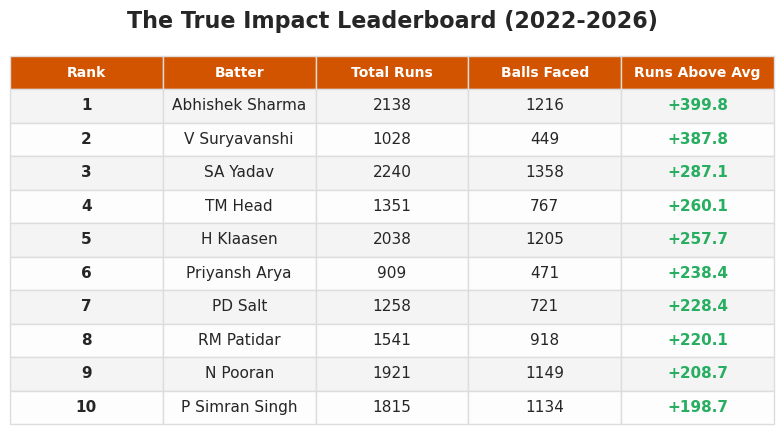

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Filter for the Modern Era (2021-2025) ---
target_seasons = ['2022', '2023', '2024', '2025','2026', 2022, 2023, 2024, 2025,2026]
modern_df = df[(df['season'].isin(target_seasons)) & (df['is_rain_reduced'] == 0)].copy()

# Filter out wides to only count legitimate balls faced
valid_balls = modern_df[modern_df['extras_wides'].isna() | (modern_df['extras_wides'] == 0)].copy()

# --- STEP 2: Calculate the League Environment (Baseline) ---
phase_environment = valid_balls.groupby('phase').agg(
    total_league_runs=('runs_batter', 'sum'),
    total_league_balls=('ball', 'count')
).reset_index()

phase_environment['league_avg_rpb'] = phase_environment['total_league_runs'] / phase_environment['total_league_balls']

# --- STEP 3: Calculate Individual Player Stats per Phase ---
player_phase_stats = valid_balls.groupby(['batter', 'phase']).agg(
    actual_runs=('runs_batter', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

impact_df = pd.merge(player_phase_stats, phase_environment[['phase', 'league_avg_rpb']], on='phase', how='left')

# --- STEP 4: The True Impact Math ---
impact_df['expected_runs'] = impact_df['balls_faced'] * impact_df['league_avg_rpb']
impact_df['true_impact_raa'] = impact_df['actual_runs'] - impact_df['expected_runs']

# --- STEP 5: Aggregate the Final Leaderboard ---
final_impact = impact_df.groupby('batter').agg(
    Total_Runs=('actual_runs', 'sum'),
    Balls_Faced=('balls_faced', 'sum'),
    True_Impact=('true_impact_raa', 'sum')
).reset_index()

# Filter for meaningful sample size (min 250 balls) and grab the Top 10
final_impact = final_impact[final_impact['Balls_Faced'] >= 250]
top_impact_batters = final_impact.sort_values(by='True_Impact', ascending=False).head(10)

# Clean up formatting for the image
top_impact_batters['True_Impact'] = "+" + top_impact_batters['True_Impact'].round(1).astype(str)
top_impact_batters = top_impact_batters.rename(columns={
    'batter': 'Batter', 
    'Total_Runs': 'Total Runs', 
    'Balls_Faced': 'Balls Faced',
    'True_Impact': 'Runs Above Avg'
}).reset_index(drop=True)

# Add Rank column
top_impact_batters.insert(0, 'Rank', range(1, 11))

# ==========================================
# --- STEP 6: FUNCTION TO DRAW THE IMAGE ---
# ==========================================
def render_impact_table(data, title, header_color):
    # Made the figure slightly taller (7x4.5) to fit 10 rows perfectly
    fig, ax = plt.subplots(figsize=(8, 4.5)) 
    ax.axis('off')
    
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=10)
        else:
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: # Bold the Rank
                cell.set_text_props(weight='bold')
            if col == 4: # Highlight the RAA column in green
                cell.set_text_props(weight='bold', color='#27ae60')
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# --- STEP 7: GENERATE THE IMAGE ---
# Using a sleek dark gold/orange for the "Impact" theme
render_impact_table(
    top_impact_batters[['Rank', 'Batter', 'Total Runs', 'Balls Faced', 'Runs Above Avg']], 
    "The True Impact Leaderboard (2022-2026)", 
    '#d35400'
)

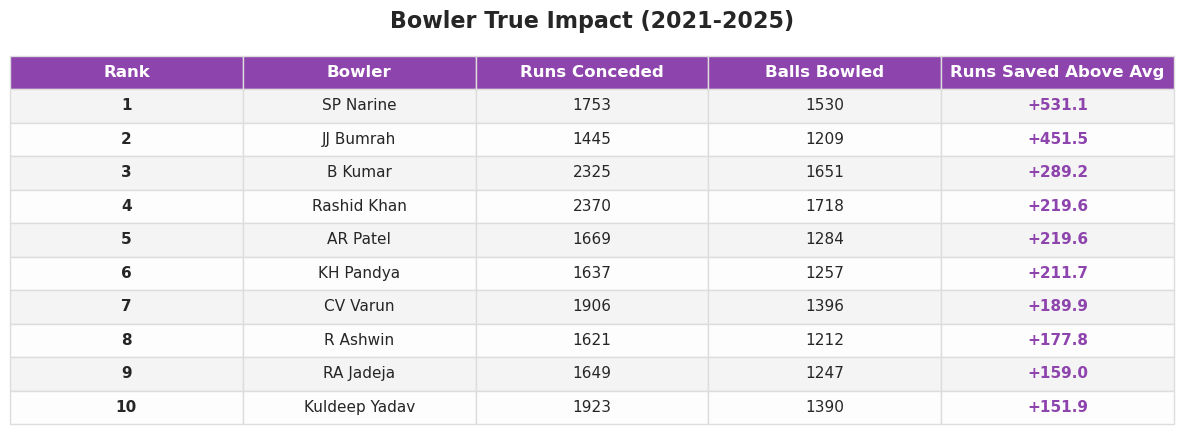

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Filter for the Modern Era (2021-2025) ---
target_seasons = ['2022', '2023', '2024', '2025','2026', 2022, 2023, 2024, 2025,2026]
modern_df = df[df['season'].isin(target_seasons)].copy()

# --- STEP 2: Define Bowler Runs and Legal Balls ---
# Bowlers are mathematically responsible for runs off the bat, wides, and no-balls
modern_df['bowler_runs'] = modern_df['runs_batter'] + modern_df['extras_wides'].fillna(0) + modern_df['extras_noballs'].fillna(0)

# Legal balls are deliveries that are NOT wides or no-balls
modern_df['is_legal_ball'] = np.where((modern_df['extras_wides'].fillna(0) == 0) & (modern_df['extras_noballs'].fillna(0) == 0), 1, 0)

# --- STEP 3: Calculate the League Environment (Baseline) ---
phase_env = modern_df.groupby('phase').agg(
    total_league_runs=('bowler_runs', 'sum'),
    total_league_balls=('is_legal_ball', 'sum') 
).reset_index()

phase_env['league_avg_rpb'] = phase_env['total_league_runs'] / phase_env['total_league_balls']

# --- STEP 4: Calculate Individual Bowler Stats per Phase ---
bowler_phase_stats = modern_df.groupby(['bowler', 'phase']).agg(
    actual_runs_conceded=('bowler_runs', 'sum'),
    legal_balls_bowled=('is_legal_ball', 'sum')
).reset_index()

impact_df = pd.merge(bowler_phase_stats, phase_env[['phase', 'league_avg_rpb']], on='phase', how='left')

# --- STEP 5: The True Impact Math ---
# Expected Runs = Legal Balls Bowled * League Average for that specific phase
impact_df['expected_runs'] = impact_df['legal_balls_bowled'] * impact_df['league_avg_rpb']

# Runs Saved Above Average (RSAA) = Expected - Actual
# A positive number means they saved runs compared to the league average!
impact_df['true_impact_rsaa'] = impact_df['expected_runs'] - impact_df['actual_runs_conceded']

# --- STEP 6: Aggregate the Final Leaderboard ---
final_impact = impact_df.groupby('bowler').agg(
    Total_Runs_Conceded=('actual_runs_conceded', 'sum'),
    Total_Legal_Balls=('legal_balls_bowled', 'sum'),
    True_Impact=('true_impact_rsaa', 'sum')
).reset_index()

# Filter for meaningful sample size (min 300 balls / 50 overs)
final_impact = final_impact[final_impact['Total_Legal_Balls'] >= 300]
top_impact_bowlers = final_impact.sort_values(by='True_Impact', ascending=False).head(10)

# Clean up formatting for the image
top_impact_bowlers['True_Impact'] = "+" + top_impact_bowlers['True_Impact'].round(1).astype(str)
top_impact_bowlers = top_impact_bowlers.rename(columns={
    'bowler': 'Bowler',
    'Total_Runs_Conceded': 'Runs Conceded',
    'Total_Legal_Balls': 'Balls Bowled',
    'True_Impact': 'Runs Saved Above Avg'
}).reset_index(drop=True)

top_impact_bowlers.insert(0, 'Rank', range(1, 11))

# ==========================================
# --- STEP 7: FUNCTION TO DRAW THE IMAGE ---
# ==========================================
def render_impact_table(data, title, header_color):
    fig, ax = plt.subplots(figsize=(12, 4.5)) 
    ax.axis('off')
    
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=12)
        else:
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: 
                cell.set_text_props(weight='bold')
            if col == 4: # Highlight the RSAA column
                cell.set_text_props(weight='bold', color='#8e44ad') # Deep purple
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# --- STEP 8: GENERATE THE IMAGE ---
# Using a striking deep purple to differentiate from the batting table
render_impact_table(
    top_impact_bowlers[['Rank', 'Bowler', 'Runs Conceded', 'Balls Bowled', 'Runs Saved Above Avg']], 
    "Bowler True Impact (2022-2026)", 
    '#8e44ad'
)

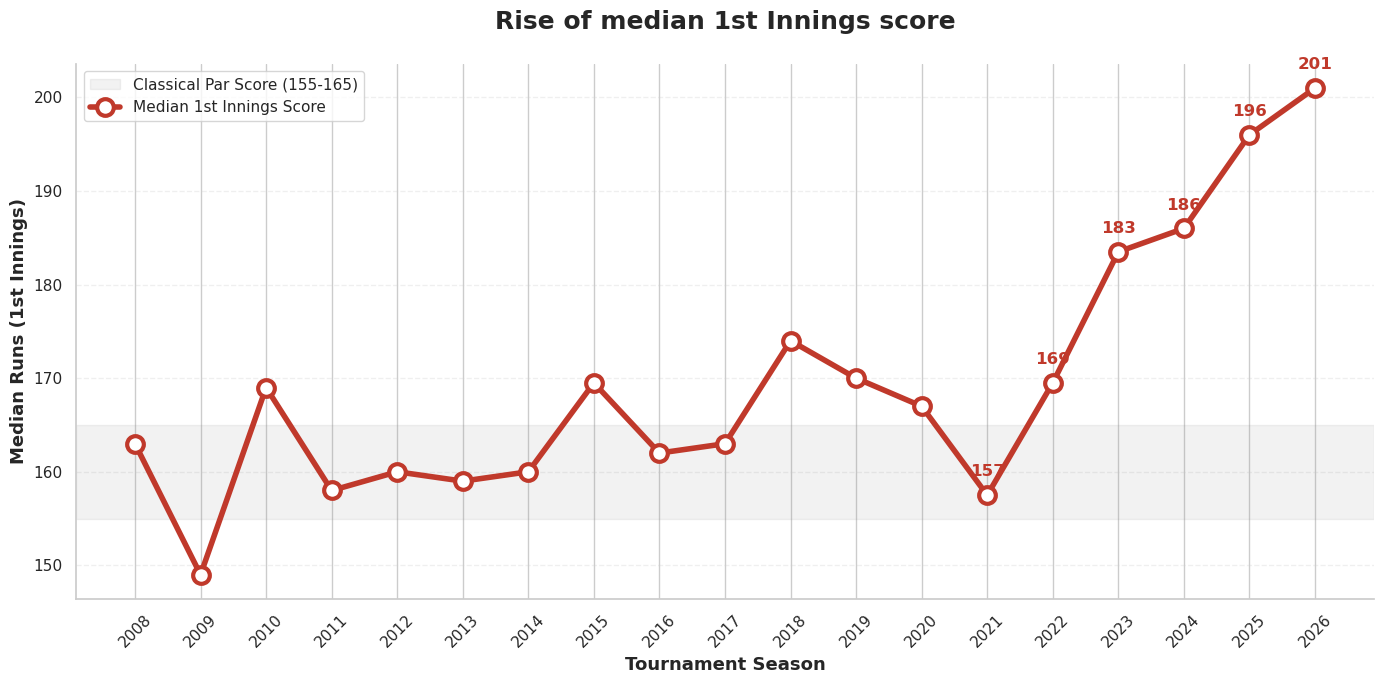

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Filter and Calculate Median Scores ---
# Exclude 2026 for a clean historical record
valid_df = df.copy()

# Get total scores for the 1st innings per match
inn1_scores = valid_df[(valid_df['innings'] == 1) & (df['is_rain_reduced']==0)].groupby(['season', 'match_id'])['runs_total'].sum().reset_index()

# Find the median score per season
inflation_trend = inn1_scores.groupby('season')['runs_total'].median().reset_index()
inflation_trend['season'] = inflation_trend['season'].astype(int)

# --- STEP 2: Build the High-Clarity Visual ---
plt.figure(figsize=(14, 7))

# 1. Add a "Classical Era" Background Shading (The 155-165 Run Zone)
plt.axhspan(155, 165, color='gray', alpha=0.1, label='Classical Par Score (155-165)')

# 2. Draw the Main Trend Line
plt.plot(
    inflation_trend['season'], 
    inflation_trend['runs_total'], 
    color='#c0392b', # Deep, authoritative red
    linewidth=4, 
    marker='o', 
    markersize=12, 
    mfc='white', # White center for the dots
    mew=3,       # Thick border for the dots
    label='Median 1st Innings Score'
)

# 3. Add Data Labels for the "Inflation Era" (2022-2025)
# This removes the guesswork—the reader sees the exact numbers
for i, row in inflation_trend.iterrows():
    if row['season'] >= 2021:
        plt.text(
            row['season'], 
            row['runs_total'] + 2, # Position slightly above the dot
            f"{int(row['runs_total'])}", 
            ha='center', 
            fontsize=12, 
            fontweight='bold', 
            color='#c0392b'
        )

# --- STEP 3: Professional Formatting ---
# Perfect X-Axis (Whole years only)
all_seasons = inflation_trend['season'].unique()
plt.xticks(ticks=all_seasons, labels=all_seasons, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Titles and Narrative Labels
plt.title('Rise of median 1st Innings score', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Median Runs (1st Innings)', fontsize=13, fontweight='bold')

# Subtle Grid and Aesthetic clean-up
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

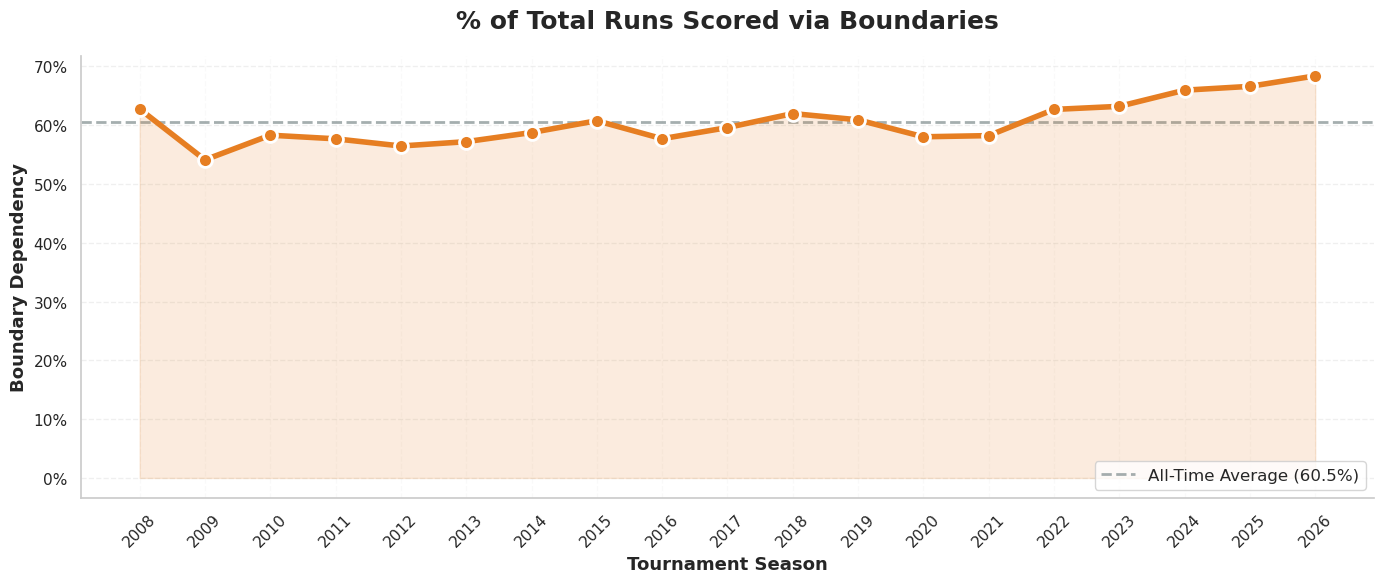

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# --- STEP 1: Filter Data & Calculate Runs ---
# Exclude 2026 for a clean timeline
valid_df = df.copy()

# Total runs off the bat per season (Ignore extras)
season_runs = valid_df.groupby('season')['runs_batter'].sum().reset_index(name='total_bat_runs')

# Boundary runs per season (4s and 6s)
boundaries = valid_df[valid_df['runs_batter'].isin([4, 6])]
season_boundaries = boundaries.groupby('season')['runs_batter'].sum().reset_index(name='boundary_runs')

# Merge and calculate the percentage
flashy_df = pd.merge(season_runs, season_boundaries, on='season')
flashy_df['boundary_dependency'] = (flashy_df['boundary_runs'] / flashy_df['total_bat_runs']) * 100

# Ensure season is an integer for the X-axis
flashy_df['season'] = flashy_df['season'].astype(int)

# --- STEP 2: Build the Upgraded "Sleek" Visual ---
plt.figure(figsize=(14, 6))
ax = plt.gca()

# Draw a smooth, elegant line instead of blocky bars
sns.lineplot(
    data=flashy_df, 
    x='season', 
    y='boundary_dependency', 
    color='#e67e22', # A vibrant, energetic orange
    linewidth=4, 
    marker='o', 
    markersize=10,
    markeredgecolor='white',
    markeredgewidth=2,
    zorder=3 # Keeps the line above the shading
)

# Add a beautiful semi-transparent fill underneath (removes the blocky feel entirely)
plt.fill_between(
    flashy_df['season'], 
    flashy_df['boundary_dependency'], 
    color='#e67e22', 
    alpha=0.15,
    zorder=2
)

# Add the All-Time Average Baseline
avg_dependency = flashy_df['boundary_dependency'].mean()
plt.axhline(
    avg_dependency, 
    color='#7f8c8d', 
    linestyle='--', 
    linewidth=2, 
    alpha=0.7, 
    label=f'All-Time Average ({avg_dependency:.1f}%)', 
    zorder=1
)

# --- STEP 3: Professional Formatting ---
# Perfect X-Axis (Whole years only)
all_seasons = flashy_df['season'].unique()
plt.xticks(ticks=all_seasons, labels=all_seasons, rotation=45, fontsize=11) 
plt.yticks(fontsize=11)

# Format Y-Axis as clean Percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Titles and Labels
plt.title('% of Total Runs Scored via Boundaries', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Boundary Dependency', fontsize=13, fontweight='bold')

# Clean, subtle gridlines
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.grid(axis='x', linestyle='--', alpha=0.1) 

plt.legend(loc='lower right', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

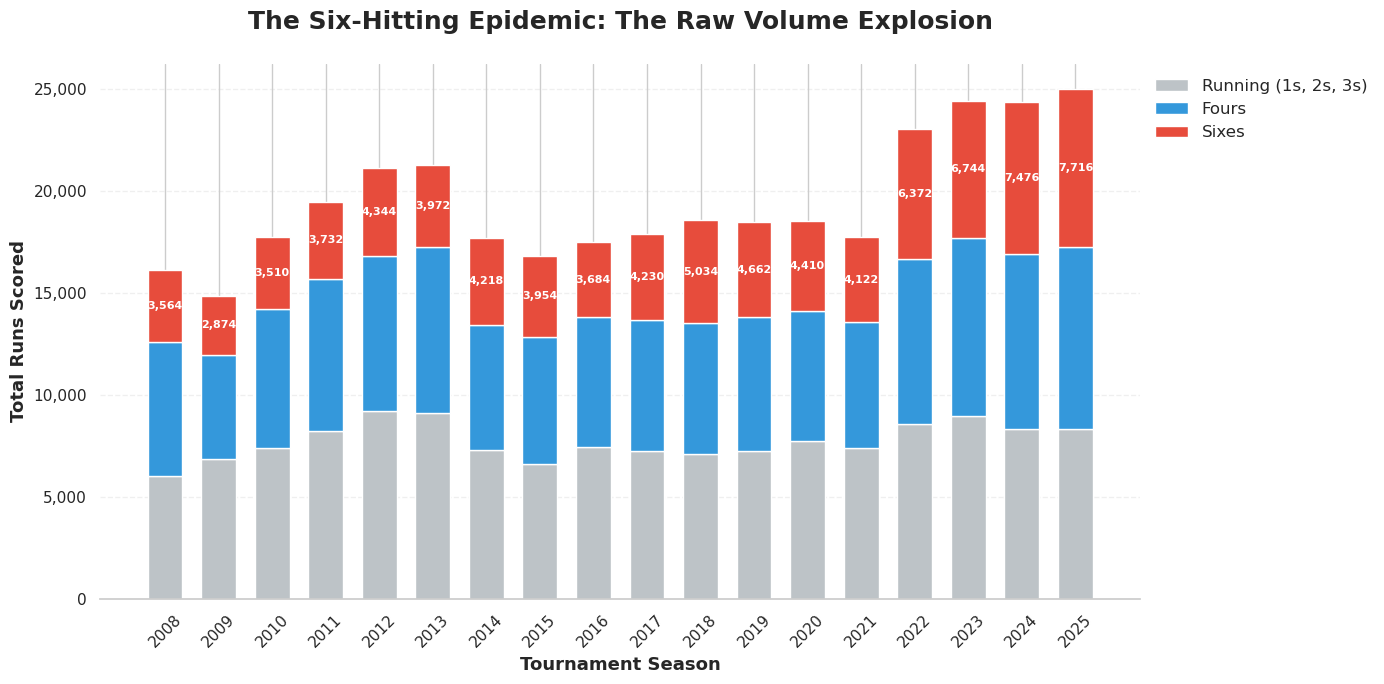

In [30]:
# --- STEP 1: Filter Data & Calculate Run Types (Absolute Runs) ---
valid_df = df[(df['season'] != 2026) & (df['season'] != '2026') & (df['is_rain_reduced'] == 0)].copy()

# Calculate runs specifically from 4s and 6s
fours_df = valid_df[valid_df['runs_batter'] == 4].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_4s')
sixes_df = valid_df[valid_df['runs_batter'] == 6].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_6s')
season_totals = valid_df.groupby('season')['runs_batter'].sum().reset_index(name='total_runs')

# Merge everything together
volume_df = season_totals.merge(fours_df, on='season', how='left').merge(sixes_df, on='season', how='left')
volume_df = volume_df.fillna(0)

# Calculate runs from running
volume_df['runs_running'] = volume_df['total_runs'] - volume_df['runs_from_4s'] - volume_df['runs_from_6s']
volume_df['season'] = volume_df['season'].astype(int)

# --- STEP 2: Build the Absolute Stacked Visual ---
fig, ax = plt.subplots(figsize=(14, 7))

# Define the deliberate color palette
color_run = '#bdc3c7' # Neutral grey (Boring/Standard)
color_4s = '#3498db'  # Solid Blue (Good)
color_6s = '#e74c3c'  # Aggressive Red (Explosive)

# Plot the absolute stacked bars (Notice we are plotting raw runs now, not pct)
ax.bar(volume_df['season'], volume_df['runs_running'], color=color_run, label='Running (1s, 2s, 3s)', edgecolor='white', width=0.65)
ax.bar(volume_df['season'], volume_df['runs_from_4s'], bottom=volume_df['runs_running'], color=color_4s, label='Fours', edgecolor='white', width=0.65)
ax.bar(volume_df['season'], volume_df['runs_from_6s'], bottom=volume_df['runs_running'] + volume_df['runs_from_4s'], color=color_6s, label='Sixes', edgecolor='white', width=0.65)

# --- STEP 3: The Narrative Annotations ---
# Let's annotate the raw number of runs from Sixes to show the sheer volume increase
for i, row in volume_df.iterrows():
    # Calculate the vertical center of the "Sixes" block
    y_pos = row['runs_running'] + row['runs_from_4s'] + (row['runs_from_6s'] / 2)
    
    ax.text(
        row['season'],
        y_pos,
        f"{int(row['runs_from_6s']):,}", # Adds commas for thousands
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=8
    )

# --- STEP 4: Professional Formatting ---
all_seasons = volume_df['season'].unique()
ax.set_xticks(all_seasons)
ax.set_xticklabels(all_seasons, rotation=45, fontsize=11)

# Format Y-Axis with commas for thousands
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Titles and Labels
plt.title('The Six-Hitting Epidemic: The Raw Volume Explosion', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Total Runs Scored', fontsize=13, fontweight='bold')

# Move the legend outside the chart to keep the bars clean
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12, frameon=False)

sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# --- STEP 5: Export and Display ---
plt.show()

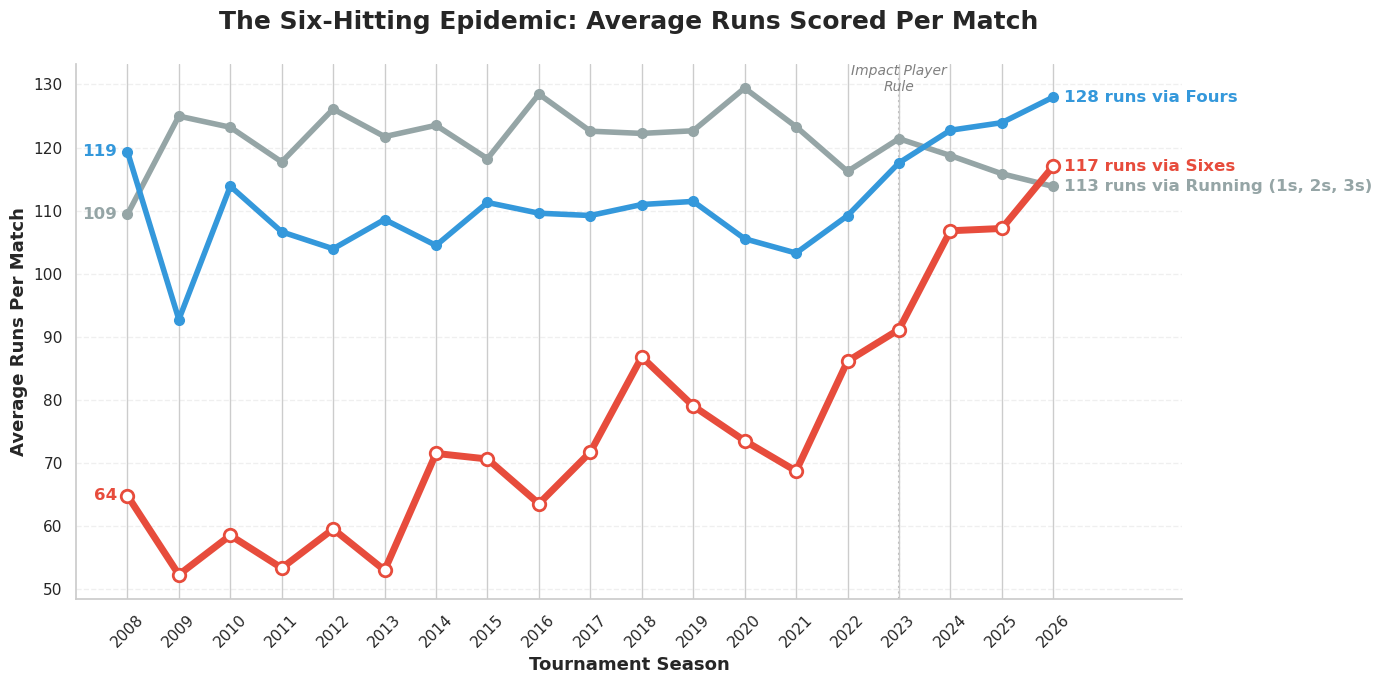

In [35]:
# --- STEP 1: Filter Data & Calculate Run Types ---
valid_df = df[(df['is_rain_reduced'] == 0)].copy()

# Calculate raw runs specifically from 4s, 6s, and totals
fours_df = valid_df[valid_df['runs_batter'] == 4].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_4s')
sixes_df = valid_df[valid_df['runs_batter'] == 6].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_6s')
season_totals = valid_df.groupby('season')['runs_batter'].sum().reset_index(name='total_runs')

# Count matches to normalize
match_counts = valid_df.groupby('season')['match_id'].nunique().reset_index(name='total_matches')

# Merge and calculate running
avg_df = season_totals.merge(fours_df, on='season').merge(sixes_df, on='season').merge(match_counts, on='season')
avg_df['runs_running'] = avg_df['total_runs'] - avg_df['runs_from_4s'] - avg_df['runs_from_6s']

# --- STEP 2: Normalize to "Runs Per Match" ---
avg_df['running_per_match'] = avg_df['runs_running'] / avg_df['total_matches']
avg_df['fours_per_match'] = avg_df['runs_from_4s'] / avg_df['total_matches']
avg_df['sixes_per_match'] = avg_df['runs_from_6s'] / avg_df['total_matches']
avg_df['season'] = avg_df['season'].astype(int)

# --- STEP 3: Build the Minimalist Visual ---
fig, ax = plt.subplots(figsize=(14, 7))

color_run = '#95a5a6' # Subdued grey
color_4s = '#3498db'  # Solid Blue
color_6s = '#e74c3c'  # Aggressive Red

# Plot the clean lines
ax.plot(avg_df['season'], avg_df['running_per_match'], color=color_run, linewidth=4, marker='o', markersize=7, label='Running')
ax.plot(avg_df['season'], avg_df['fours_per_match'], color=color_4s, linewidth=4, marker='o', markersize=7, label='Fours')
ax.plot(avg_df['season'], avg_df['sixes_per_match'], color=color_6s, linewidth=5, marker='o', markersize=9, mfc='white', mew=2, label='Sixes')

# --- STEP 4: Direct Labeling (Zero Clutter) ---
# We only annotate the very first year (2008) and the very last year to show the shift
first_year = avg_df['season'].min()
last_year = avg_df['season'].max()

lines_to_label = [
    ('running_per_match', color_run, 'Running (1s, 2s, 3s)'),
    ('fours_per_match', color_4s, 'Fours'),
    ('sixes_per_match', color_6s, 'Sixes')
]

for col, color, label_text in lines_to_label:
    first_val = avg_df[avg_df['season'] == first_year][col].values[0]
    last_val = avg_df[avg_df['season'] == last_year][col].values[0]
    
    # Label the starting value on the left
    ax.text(first_year - 0.2, first_val, f"{int(first_val)}", color=color, ha='right', va='center', fontweight='bold', fontsize=12)
    
    # Label the ending value AND the category name on the right (Replaces the Legend!)
    ax.text(last_year + 0.2, last_val, f"{int(last_val)} runs via {label_text}", color=color, ha='left', va='center', fontweight='bold', fontsize=12)

# Add a subtle vertical line to mark the Impact Player era
ax.axvline(2023, color='gray', linestyle=':', alpha=0.5, zorder=0)
ax.text(2023, ax.get_ylim()[1], 'Impact Player\nRule', color='gray', ha='center', va='top', fontsize=10, style='italic')

# --- STEP 5: Professional Formatting ---
ax.set_xticks(avg_df['season'].unique())
ax.set_xticklabels(avg_df['season'].unique(), rotation=45, fontsize=11)

# Expand X-axis limits slightly to fit our new side-labels perfectly
ax.set_xlim(first_year - 1, last_year + 2.5)

plt.title('The Six-Hitting Epidemic: Average Runs Scored Per Match', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Average Runs Per Match', fontsize=13, fontweight='bold')

# Turn off the legend, right border, and top border for maximum cleanliness
sns.despine()
ax.legend_.remove() if ax.get_legend() else None
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# --- STEP 6: Export and Display ---
plt.show()

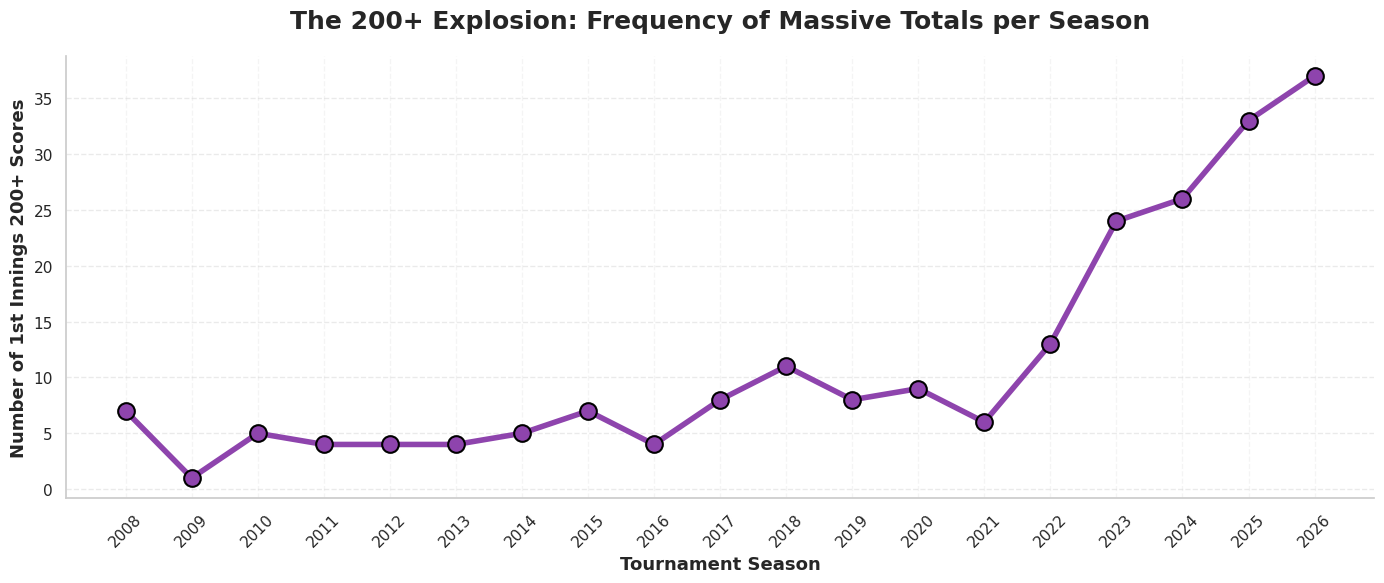

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Filter Data & Calculate 1st Innings Scores ---
# Convert to string temporarily to safely catch both integer 2026 and string '2026'
valid_df = df.copy()

# Get total scores for the 1st innings per match
inn1_scores = valid_df[(valid_df['innings'] == 1) & (valid_df['is_rain_reduced']==0)].groupby(['season', 'match_id'])['runs_total'].sum().reset_index()

# --- STEP 2: Flag and Count the 200+ Scores ---
inn1_scores['is_200_plus'] = (inn1_scores['runs_total'] >= 200).astype(int)
monster_scores = inn1_scores.groupby('season')['is_200_plus'].sum().reset_index(name='count_200_plus')

# Ensure 'season' is treated as an integer for perfectly clean axis labels
monster_scores['season'] = monster_scores['season'].astype(int)

# --- STEP 3: Build the Professional Visual ---
plt.figure(figsize=(14, 6)) # Made slightly wider to fit all years comfortably

# Draw the line
sns.lineplot(
    data=monster_scores, 
    x='season', 
    y='count_200_plus', 
    color='#8e44ad', # A striking deep purple
    linewidth=4, 
    marker='o', 
    markersize=12,
    markeredgecolor='black',
    markeredgewidth=1.5
)

# --- THE FIX: Perfect X-Axis Formatting ---
# Extract all the unique years and force matplotlib to tick exactly on those numbers
all_seasons = monster_scores['season'].unique()
plt.xticks(ticks=all_seasons, labels=all_seasons, rotation=45, fontsize=11) 
plt.yticks(fontsize=11)

# Formatting and Labels
plt.title('The 200+ Explosion: Frequency of Massive Totals per Season', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Number of 1st Innings 200+ Scores', fontsize=13, fontweight='bold')

# Add clean gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.grid(axis='x', linestyle='--', alpha=0.2) 

sns.despine()
plt.tight_layout()
plt.show()

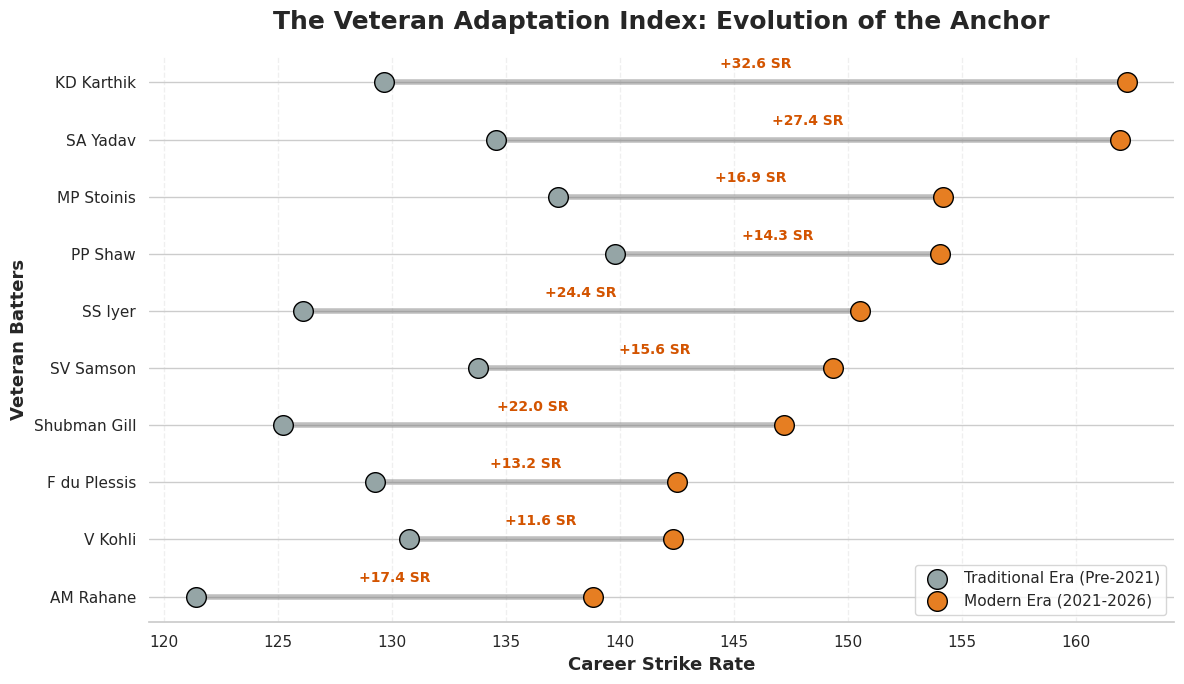

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Split the Eras ---
# Traditional Era: Up to 2020
trad_df = df[df['season'].astype(str).astype(int) <= 2020].copy()
# Modern Era: 2021 to 2025
modern_df = df[(df['season'].astype(str).astype(int) >= 2021)].copy()

# Helper function to get valid balls and runs
def get_batter_stats(data):
    valid_balls = data[data['extras_wides'].isna() | (data['extras_wides'] == 0)]
    stats = valid_balls.groupby('batter').agg(
        runs=('runs_batter', 'sum'),
        balls=('ball', 'count')
    ).reset_index()
    stats['strike_rate'] = (stats['runs'] / stats['balls']) * 100
    return stats

# --- STEP 2: Calculate Stats for Both Eras ---
trad_stats = get_batter_stats(trad_df)
trad_stats = trad_stats.rename(columns={'runs': 'trad_runs', 'balls': 'trad_balls', 'strike_rate': 'trad_sr'})

modern_stats = get_batter_stats(modern_df)
modern_stats = modern_stats.rename(columns={'runs': 'mod_runs', 'balls': 'mod_balls', 'strike_rate': 'mod_sr'})

# --- STEP 3: Merge and Filter for Veterans ---
veteran_df = pd.merge(trad_stats, modern_stats, on='batter', how='inner')

# Filter for players who faced at least 400 balls in BOTH eras (true veterans)
veteran_df = veteran_df[(veteran_df['trad_balls'] >= 400) & (veteran_df['mod_balls'] >= 400)].copy()

# Calculate the jump in Strike Rate
veteran_df['sr_jump'] = veteran_df['mod_sr'] - veteran_df['trad_sr']

# Get the Top 10 veterans who adapted the most (biggest positive jump)
top_adapters = veteran_df.sort_values('sr_jump', ascending=False).head(10).reset_index(drop=True)

# Sort them so the highest modern strike rate is at the top of the chart
top_adapters = top_adapters.sort_values('mod_sr', ascending=True).reset_index(drop=True)

# --- STEP 4: Build the Dumbbell Plot ---
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Draw the lines connecting the two eras
plt.hlines(y=top_adapters['batter'], xmin=top_adapters['trad_sr'], xmax=top_adapters['mod_sr'], color='gray', alpha=0.5, linewidth=4, zorder=1)

# Draw the Traditional Era dots (Gray)
plt.scatter(top_adapters['trad_sr'], top_adapters['batter'], color='#95a5a6', s=200, label='Traditional Era (Pre-2021)', zorder=2, edgecolors='black')

# Draw the Modern Era dots (Orange/Explosive)
plt.scatter(top_adapters['mod_sr'], top_adapters['batter'], color='#e67e22', s=200, label='Modern Era (2021-2026)', zorder=3, edgecolors='black')

# --- STEP 5: Annotate the Jump ---
for i, row in top_adapters.iterrows():
    # Print the exact SR jump directly on the line
    plt.text(
        (row['trad_sr'] + row['mod_sr']) / 2, 
        i + 0.25, 
        f"+{row['sr_jump']:.1f} SR", 
        color='#d35400', 
        ha='center', 
        fontweight='bold',
        fontsize=10
    )

# --- STEP 6: Professional Formatting ---
plt.title('The Veteran Adaptation Index: Evolution of the Anchor', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Career Strike Rate', fontsize=13, fontweight='bold')
plt.ylabel('Veteran Batters', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='lower right', fontsize=11)
sns.despine(left=True) # Remove left spine for cleaner look with names
plt.tight_layout()
plt.show()

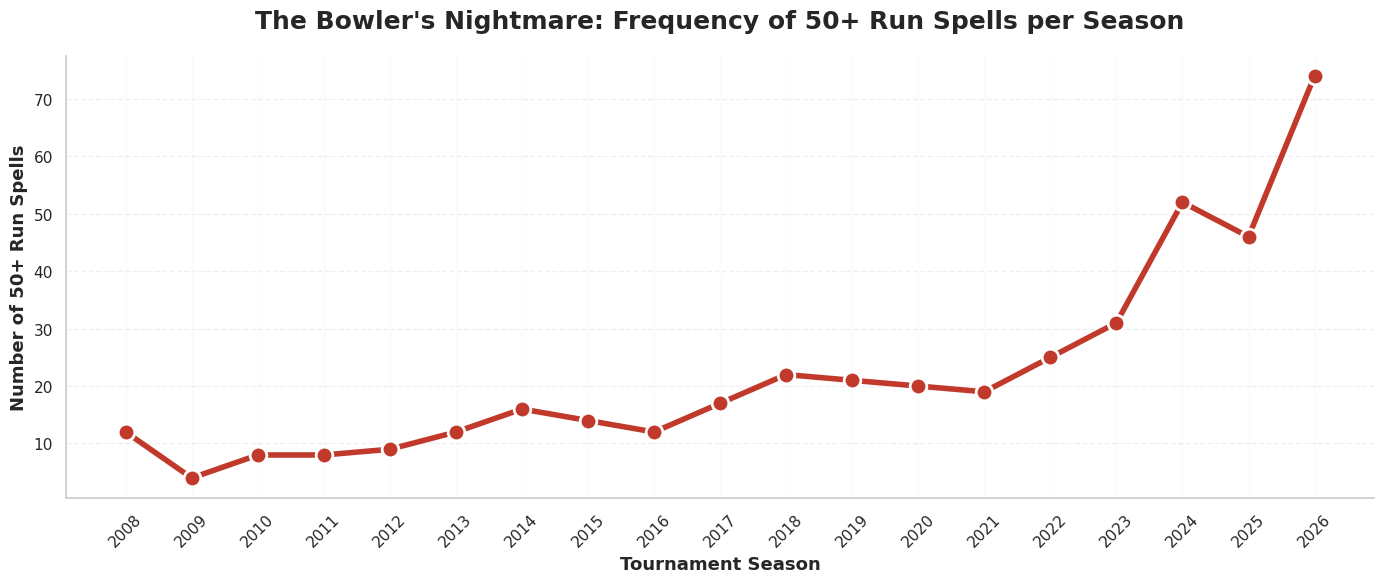

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Filter Data & Calculate Runs Conceded ---
# Exclude 2026 for a clean timeline
valid_df = df[df['is_rain_reduced']==0].copy()

# Bowler runs conceded = runs off the bat + wides + no-balls
valid_df['bowler_runs_conceded'] = valid_df['runs_batter'] + valid_df['extras_wides'].fillna(0) + valid_df['extras_noballs'].fillna(0)

# Calculate total runs conceded by each bowler in every single match
match_bowler_stats = valid_df.groupby(['season', 'match_id', 'bowler'])['bowler_runs_conceded'].sum().reset_index()

# --- STEP 2: Flag and Count the 50+ Run Spells ---
# Create a flag if the bowler gave up 50 or more runs in the match
match_bowler_stats['is_50_plus'] = (match_bowler_stats['bowler_runs_conceded'] >= 50).astype(int)

# Count how many times this happened per season
nightmare_spells = match_bowler_stats.groupby('season')['is_50_plus'].sum().reset_index(name='count_50_plus')

# Ensure 'season' is treated as an integer for clean axis labels
nightmare_spells['season'] = nightmare_spells['season'].astype(int)

# --- STEP 3: Build the Professional Visual ---
plt.figure(figsize=(14, 6))

# Draw the line
sns.lineplot(
    data=nightmare_spells, 
    x='season', 
    y='count_50_plus', 
    color='#c0392b', # A danger-red to signify bowling damage
    linewidth=4, 
    marker='o', 
    markersize=12,
    markeredgecolor='white',
    markeredgewidth=2
)

# Perfect X-Axis Formatting
all_seasons = nightmare_spells['season'].unique()
plt.xticks(ticks=all_seasons, labels=all_seasons, rotation=45, fontsize=11) 
plt.yticks(fontsize=11)

# Formatting and Labels
plt.title("The Bowler's Nightmare: Frequency of 50+ Run Spells per Season", fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Number of 50+ Run Spells', fontsize=13, fontweight='bold')

# Add clean gridlines
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.grid(axis='x', linestyle='--', alpha=0.1) 

sns.despine()
plt.tight_layout()
plt.show()